In [35]:
import numpy as np
import pandas as pd
import uproot
from xgboost import XGBRegressor

# --- 1. 配置参数 ---
BASE_PATH = "/data/home/zzh/data/Dataset_Filted/CosmicRay"
FILES = {
    "proton": "QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root",
    "he":     "QF_He_addweight_rho_2.5e13_5.0e17_V3.root",
    "cno":    "QF_CNO_addweight_rho_2.5e13_5.0e17_V3.root",
    "fe":     "QF_Fe_addweight_rho_2.5e13_5.0e17_V3.root",
    "mgalsi": "QF_MgAlSi_addweight_rho_2.5e13_5.0e17_V3.root"
}

CUTS = (
    "rec_Eage > 0 and Redge > 0 and NuW3 > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high"
)


# 阈值变量
r_cut_low, r_cut_high = 300, 450
theta_cut_low, theta_cut_high = np.deg2rad([0, 35])
log10TeV_low=3.7; log10TeV_high=4.3

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")
import json
        
# 加载线性参数
with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
    lp = json.load(f)
intercept  = lp["intercept"]
coef_NuW3  = lp["coef"][0]
coef_theta = lp["coef"][1]


# --- 3. 核心处理函数 ---
def process_cosmic_ray(name, filename):
    with uproot.open(f"{BASE_PATH}/{filename}") as f:
        # 读取数据
        branches = ["E", "theta", "phi", "corex", "corey", "rec_x", "rec_y", 
                    "rec_theta", "rec_phi", "rec_Eage", "Redge", "NpE3", "NuM1", "NuW3", "weightGaisser", "weightHorandol"]
        df = f["Rec"].arrays(branches, library="pd")
        
        print(f"Processing {name}: Entries={len(df)}, Weights={df['weightGaisser'].sum():.2e}")

        # 1. 基础物理筛选
        df = df.query(CUTS).copy()
        
        # 2. 计算特征量
        df["R_ue"] = np.log10((1e-4 + df["NuM1"]) / (df["NpE3"]))
        df["r"] = np.hypot(df['rec_x'], df['rec_y']) # 比 sqrt(x^2+y^2) 更快
        
        # 3. 半径进一步筛选
        df = df[(df["r"] > r_cut_low) & (df["r"] < r_cut_high)]
        df['NuW3'] = np.log10(df['NuW3'])
        # 4. XGBoost 能量修正
        features = df[["NuW3", "rec_theta"]].values
        df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
        print(f"     Finished {name}: Remaining Entries={len(df)}")

        return df[(df['recE']>log10TeV_low) & (df['recE']<log10TeV_high)]

# --- 4. 批量执行 ---
dfs = {name: process_cosmic_ray(name, path) for name, path in FILES.items()}
# 如果你需要解包到独立变量（虽然推荐直接用字典 dfs['proton']）
proton_df, he_df, cno_df, fe_df, mgalsi_df = dfs.values()
df_all_components = pd.concat(dfs.values(), ignore_index=True)
df_all_components['Eage'] = df_all_components['rec_Eage'] 
# ==========================================                



import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def load_pos(flag:int):
    ED_pos_file = None
    MD_pos_file = None
    script_dir = "/data/home/zzh/data/Dataset_Filted/config"
    if flag==7:
        ED_pos_file=f'{script_dir}/ED_pos_all_MC.txt'
        MD_pos_file=f'{script_dir}/MD_pos_all_MC.txt'
    else:
        MD_pos_file=f'{script_dir}/MD_pos_1188.txt'
        if flag>20191224 and flag<20201201:
            ED_pos_file=f'{script_dir}/ED_pos_half.txt'
        elif flag>20201130 and flag<20210720:
            ED_pos_file=f'{script_dir}/ED_pos_3978.txt'
        elif flag>20210719 and flag<20210807:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20210720.txt'
        elif flag>20210806 and flag<20210818:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20210807.txt'
        elif flag>20210817 and flag<20220525:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20210818.txt'
        elif flag>20220525 and flag<20220601:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20220520.txt'
        elif flag>20220531 and flag<20220705:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20220601.txt'
        elif flag>20220704:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20220705.txt'
    
    if ED_pos_file is not None:
        if os.path.exists(ED_pos_file) and os.path.exists(MD_pos_file):
            ED_pos=pd.read_csv(ED_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
            MD_pos=pd.read_csv(MD_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
            return ED_pos,MD_pos
    else:

        raise ValueError("wrong flag")
    
def event_plot_npz(index, hitsE_all, hitsM_all, df_params, flag=20240101, figpath=None):
    # 1. 加载阵列全量位置作为背景
    # 依然需要 load_pos 来获取该 flag 下所有探测器的坐标
    ED_pos, MD_pos = load_pos(flag)

    # 2. 提取当前事例的 hit 数据 (N, 5) -> x, y, r, pe, dt
    hE = hitsE_all[index]
    hM = hitsM_all[index]
    
    # 提取重建参数
    row = df_params.iloc[index]
    core = [row['rec_x'], row['rec_y']]
    theta, phi = row['rec_theta'], row['rec_phi']

    # 3. 计算指向箭头
    dy = np.sin(theta) * np.cos(phi)
    dx = -np.sin(theta) * np.sin(phi)
    dr = np.sqrt(dx**2 + dy**2)
    arrow_len = 200
    if dr > 0:
        dx, dy = dx * arrow_len / dr, dy * arrow_len / dr

    # 4. 开始绘图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 左图：ED Hits ---
    # 背景：所有 ED 位置
    ax1.scatter(ED_pos['x'], ED_pos['y'], c='lightgray', s=1, alpha=0.3, label='Detectors')
    # 前景：命中的 ED (hE[:, 3] 是 pe)
    sc1 = ax1.scatter(hE[:, 0], hE[:, 1], c=np.log10(hE[:, 3] + 1), 
                      cmap='viridis', s=5, zorder=3)
    
    ax1.scatter(core[0], core[1], c='red', s=60, marker='x', label='Core', zorder=5)
    ax1.arrow(core[0], core[1], dx, dy, color='orange', width=2, head_width=15, zorder=6)
    
    ax1.set_title('ED Channel Hits', fontweight='bold')
    fig.colorbar(sc1, ax=ax1, label='log10 PE')

    # --- 右图：MD Hits ---
    # 背景：所有 MD 位置
    ax2.scatter(MD_pos['x'], MD_pos['y'], c='lightgray', s=4, alpha=0.3)
    # 前景：命中的 MD
    sc2 = ax2.scatter(hM[:, 0], hM[:, 1], c=np.log10(hM[:, 3] + 1), 
                      cmap='viridis', s=15, zorder=3)
    
    ax2.scatter(core[0], core[1], c='red', s=60, marker='x', zorder=5)
    
    ax2.set_title('MD Channel Hits', fontweight='bold')
    fig.colorbar(sc2, ax=ax2, label='log10 PE')

    # 格式化标题
    res_info = (f"Event {index} | R_mean: {row['R_mean']:.2f}\n"
                f"Core: [{core[0]:.1f}, {core[1]:.1f}] | "
                f"Theta: {np.degrees(theta):.1f}°, Phi: {np.degrees(phi):.1f}°")
    plt.suptitle(res_info, fontsize=12)
    
    for ax in [ax1, ax2]:
        ax.set_aspect('equal') # 保持物理比例
        ax.set_xlabel('X [m]')
        ax.set_ylabel('Y [m]')
        ax.set_xlim(-650,650)
        ax.set_ylim(-650,650)
        ax.grid(True, linestyle=':', alpha=0.4)

    plt.tight_layout()
    # if figpath:
    #     plt.savefig(figpath, dpi=150, bbox_inches='tight')
    plt.show()

def energy_rec(df):
    df['NuW3'] = pd.to_numeric(df['NuW3'], errors='coerce')
    df['NuW3'] = np.log10(df['NuW3'])
    # 4. XGBoost 能量修正
    features = df[["NuW3", "rec_theta"]].values
    df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
    return df


# --- 1. 加载数据 ---

# R_ue control region df
# one_day_data=pd.read_csv("/data/home/zzh/data/Dataset_Filted/Experiment/exp_muons/2023_0101_1e10_V04_dataset_muon.csv"); print(f'Loaded {len(one_day_data)}')
one_day_file="/data/home/zzh/data/Dataset_Filted/Experiment/1e12_V04/1e12_V04-1.25_2021_ALL_MERGED.npz"
one_day= np.load(one_day_file, allow_pickle=True)
one_day_data = pd.DataFrame(one_day['params'], columns=one_day['param_names']); del one_day
one_day_data = energy_rec(one_day_data)
# one_day_data = one_day_data[(one_day_data['recE']>log10TeV_low) & (one_day_data['recE']<log10TeV_high) & (one_day_data['R_ue']>-2.2)]
one_day_data['rec_x']= pd.to_numeric(one_day_data['rec_x'], errors='coerce'); one_day_data['rec_y'] = pd.to_numeric(one_day_data['rec_y'], errors='coerce'); one_day_data['rec_r']=np.sqrt(one_day_data['rec_x']**2 + one_day_data['rec_y']**2)
one_day_df = one_day_data[(one_day_data['rec_r']>r_cut_low) & (one_day_data['rec_r']<r_cut_high) & (one_day_data['rec_theta'] > theta_cut_low) & (one_day_data['rec_theta'] < theta_cut_high)]
print(f"One day data: {len(one_day_df)} events")


Processing proton: Entries=14217778, Weights=1.90e+02
     Finished proton: Remaining Entries=1698410
Processing he: Entries=14210418, Weights=2.03e+02
     Finished he: Remaining Entries=1166415
Processing cno: Entries=14218958, Weights=7.65e+01
     Finished cno: Remaining Entries=891738
Processing fe: Entries=14217887, Weights=7.40e+01
     Finished fe: Remaining Entries=736239
Processing mgalsi: Entries=14220016, Weights=3.57e+01
     Finished mgalsi: Remaining Entries=813815
One day data: 9041 events
------------------------------
Processing Experimental Data...


SyntaxError: Python keyword not valid identifier in numexpr query (<unknown>, line 1)

------------------------------
Processing Experimental Data...
Exp Data: 57325 -> 9040 events (after cuts)
------------------------------
Merging MC Components...
Total MC Events: 5824
Total MC Flux Weight: 6.96e-04
------------------------------
Calculating Systematics Shifts (Data - MC)...

[recE Shift]
  Mean Data: 3.8656
  Mean MC  : 3.8760
  Shift (Data-MC): -0.0105
  Recommended UNC_E: 0.0105 (or conservative 0.05)

[R_ue Shift]
  Mean Data: -1.3431
  Mean MC  : -1.3302
  Shift (Data-MC): -0.0129
  Recommended UNC_RUE: 0.0129

[Eage Shift]
  Mean Data: 1.2119
  Mean MC  : 1.1439
  Shift (Data-MC): 0.0681, 0.0662
  Recommended UNC_EAGE: 0.0681

[rec_theta Shift]
  Mean Data: 0.4097
  Mean MC  : 0.4193
  Shift (Data-MC): -0.0097
  Recommended UNC_THETA: 0.0097


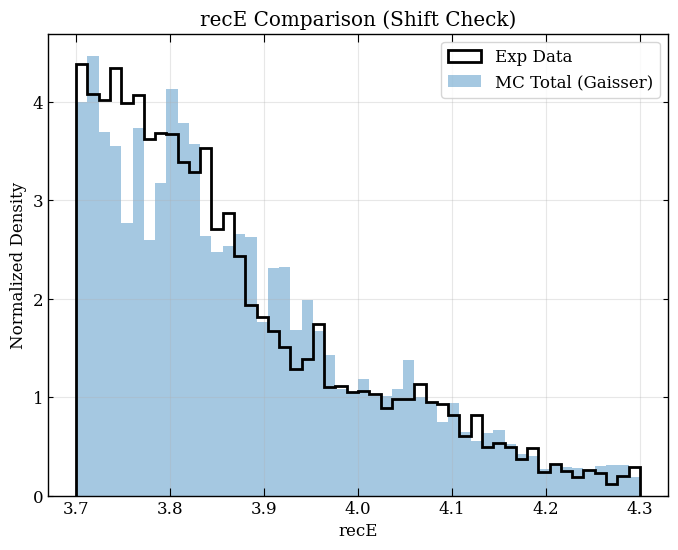

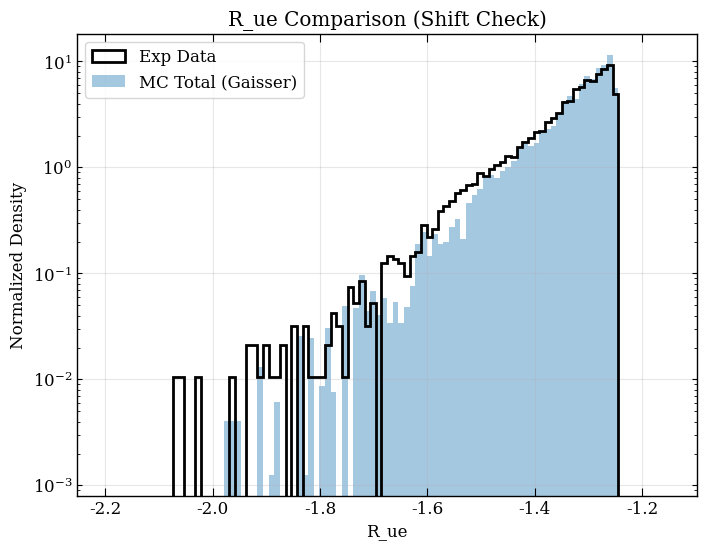

In [42]:

import numpy as np
import pandas as pd

# 切选字符串 (注意：NuW3 在 query 时通常是线性的，未取 log 前)
CUTS_QUERY = (
    "rec_Eage > 0 and NuW3 > 0 "
    "and @theta_cut_low < rec_theta < @theta_cut_high "
    "and @log10TeV_low < recE < @log10TeV_high "
    "and -2.2< R_ue < -1.25 "  # CR 区域切选 (可以根据需要调整)
)
CUTS_QUERY_exp = (
    "Eage > 0 and NuW3 > 0 "
    "and @theta_cut_low < rec_theta < @theta_cut_high "
    "and @log10TeV_low < recE < @log10TeV_high "
    "and -2.2< R_ue < -1.25 "
)


# ==========================================
# 1. 处理实验数据 (Apply Same Cuts)
# ==========================================
print("-" * 30)
print("Processing Experimental Data...")

# 1. 复制一份以免修改原数据
exp_df = one_day_data.copy()

# 2. 补充必要的几何变量 (如果 CSV 里没有 r)
# 假设 rec_x, rec_y 存在于 CSV 中
if 'r' not in exp_df.columns:
    exp_df["r"] = np.hypot(exp_df['rec_x'], exp_df['rec_y'])

# 3. 应用基础物理切选 (rec_Eage, Theta, etc.)
# 假设 CSV 列名与 MC 保持一致
before_cut = len(exp_df)
exp_df = exp_df.query(CUTS_QUERY_exp)

# 4. 应用半径切选
exp_df = exp_df[(exp_df["r"] > r_cut_low) & (exp_df["r"] < r_cut_high)]

# 5. 应用能量切选 (recE 已存在于 CSV)
exp_df = exp_df[(exp_df['recE'] > log10TeV_low) & (exp_df['recE'] < log10TeV_high)]

print(f"Exp Data: {before_cut} -> {len(exp_df)} events (after cuts)")

# ==========================================
# 2. 合并 MC 数据 (Weighted Concatenation)
# ==========================================
print("-" * 30)
print("Merging MC Components...")

# 将之前处理好的 5 个 DataFrame 合并
# 假设 dfs 是上一段代码生成的字典
mc_df_list = []
for name, df in dfs.items():
    temp_df = df.copy()
    temp_df['component'] = name  # 标记成分 (可选)
    mc_df_list.append(temp_df)

mc_total = pd.concat(mc_df_list, ignore_index=True)
mc_total = mc_total.query(CUTS_QUERY)  # 对合并后的 MC 数据应用同样的切选
print(f"Total MC Events: {len(mc_total)}")
print(f"Total MC Flux Weight: {mc_total['weightGaisser'].sum():.2e}")

# ==========================================
# 3. 计算偏移量 (Shift Calculation)
# ==========================================
print("-" * 30)
print("Calculating Systematics Shifts (Data - MC)...")

def get_weighted_stats(values, weights=None, val_range=None):
    """计算加权均值"""
    if weights is None:
        weights = np.ones(len(values))
    # 如果提供了 val_range，可以先筛选出范围内的值和对应的权重
    if val_range is not None:
        mask = (values >= val_range[0]) & (values <= val_range[1])
        values_masked = values[mask]
        weights_masked = weights[mask]
    else:
        values_masked = values
        weights_masked = weights
    # 计算加权均值
    if np.sum(weights_masked) == 0:
        return np.nan, np.nan
    else:
        average = np.average(values_masked, weights=weights_masked)
        # 也可以计算加权标准差用于参考
        variance = np.average((values_masked - average)**2, weights=weights_masked)
        return average, np.sqrt(variance)

# --- A. 计算 recE 的偏移 ---
# Exp (无权重或权重为1)
mu_exp_E, std_exp_E = get_weighted_stats(exp_df['recE'])
# MC (使用 Gaisser 权重)
mu_mc_E, std_mc_E = get_weighted_stats(mc_total['recE'], mc_total['weightGaisser'])

diff_E = mu_exp_E - mu_mc_E
print(f"\n[recE Shift]")
print(f"  Mean Data: {mu_exp_E:.4f}")
print(f"  Mean MC  : {mu_mc_E:.4f}")
print(f"  Shift (Data-MC): {diff_E:.4f}") 
print(f"  Recommended UNC_E: {abs(diff_E):.4f} (or conservative {max(0.05, abs(diff_E)):.2f})")

# --- B. 计算 R_ue 的偏移 ---
# 注意：确保 Data 也是在 CR 区域 (Rue > -2)
# 代码逻辑中 exp_df 已经是 CR 数据了，但为了严谨，我们计算 Shift 时
# 最好限制 MC 也只看 Rue > -2 的部分 (Sideband Comparison)，或者看峰值位置
# 这里我们直接比较整体均值 (假设都在 Background Region)

# 如果想更严谨，取 -4 < Rue < -1.8 这种纯背景区计算
# 这里演示全范围计算（基于前面已经做过的筛选）
mu_exp_R, std_exp_R = get_weighted_stats(exp_df['R_ue'])
mu_mc_R, std_mc_R = get_weighted_stats(mc_total['R_ue'], mc_total['weightGaisser'])

diff_R = mu_exp_R - mu_mc_R
print(f"\n[R_ue Shift]")
print(f"  Mean Data: {mu_exp_R:.4f}")
print(f"  Mean MC  : {mu_mc_R:.4f}")
print(f"  Shift (Data-MC): {diff_R:.4f}")
print(f"  Recommended UNC_RUE: {abs(diff_R):.4f}")

# --- C. 计算 Eage 的偏移 ---
age_range = (0.8, 1.6)  # Eage 的合理范围
mu_exp_Eage, std_exp_Eage = get_weighted_stats(exp_df['Eage'], val_range=age_range)
mu_mc_Eage, std_mc_Eage = get_weighted_stats(mc_total['rec_Eage'], mc_total['weightGaisser'], val_range=age_range)
mu_mc_Eage_horandel, std_mc_Eage_horandel = get_weighted_stats(mc_total['rec_Eage'], mc_total['weightHorandol'], val_range=age_range)
diff_Eage = mu_exp_Eage - mu_mc_Eage
diff_Eage_horandel = mu_exp_Eage - mu_mc_Eage_horandel
print(f"\n[Eage Shift]")
print(f"  Mean Data: {mu_exp_Eage:.4f}")
print(f"  Mean MC  : {mu_mc_Eage:.4f}")
print(f"  Shift (Data-MC): {diff_Eage:.4f}, {diff_Eage_horandel:.4f}")
print(f"  Recommended UNC_EAGE: {abs(diff_Eage):.4f}")

# --- D. 计算 rec_theta 的偏移 ---
mu_exp_theta, std_exp_theta = get_weighted_stats(exp_df['rec_theta'])
mu_mc_theta, std_mc_theta = get_weighted_stats(mc_total['rec_theta'], mc_total['weightGaisser'])

diff_theta = mu_exp_theta - mu_mc_theta
print(f"\n[rec_theta Shift]")
print(f"  Mean Data: {mu_exp_theta:.4f}")
print(f"  Mean MC  : {mu_mc_theta:.4f}")
print(f"  Shift (Data-MC): {diff_theta:.4f}")
print(f"  Recommended UNC_THETA: {abs(diff_theta):.4f}")
# ==========================================
# 4. 可视化验证 (强烈建议)
# ==========================================
import matplotlib.pyplot as plt

def plot_comparison(var_name, bins, range_val, log=False):
    plt.figure(figsize=(8, 6))
    
    # Plot Exp (Density)
    plt.hist(exp_df[var_name], bins=bins, range=range_val, density=True,
             histtype='step', color='black', label='Exp Data', lw=2)
    
    # Plot MC (Density + Weighted)
    plt.hist(mc_total[var_name], bins=bins, range=range_val, weights=mc_total['weightGaisser'],
             density=True, histtype='stepfilled', alpha=0.4, label='MC Total (Gaisser)')
    
    plt.title(f"{var_name} Comparison (Shift Check)")
    plt.xlabel(var_name)
    plt.ylabel("Normalized Density")
    plt.legend()
    if log: plt.yscale('log')
    plt.grid(alpha=0.3)
    plt.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_{var_name}_shift.pdf", dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison('recE', 50, (3.7, 4.3))
# R_ue 通常看 -4 到 0 的范围
plot_comparison('R_ue', 100, (-2.2, -1.15), log=True)
# plot_comparison('rec_Eage', 50, (0.8, 1.8))
# plot_comparison('rec_theta', 50, (0, 0.63))


In [37]:
print("Columns in exp_df:", exp_df.columns.tolist())

Columns in exp_df: ['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness', 'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE1', 'NpE2', 'NpE3', 'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y', 'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat', 'rec_r', 'r']


In [65]:
import pandas as pd
import numpy as np
import re
import uproot
from scipy.integrate import quad


r_low=300
r_high=450
theta_low=0
theta_high=35 / 180.0 * np.pi

Eage_low=0.8
Eage_high=1.6
# R_ue_high=-5.0
log10TeV_low=3.7
log10TeV_high=4.3
rho40_low=500
rho40_high=2500
pincness_low=0.93
pincness_high=0.98
compactness_low=0
compactness_high=0.3

from xgboost import XGBRegressor
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")


def filter_dataset_optimized(npz_file, output_file=None, mc=True, R_mean_cut=True, is_csv=False, radius_cut=True):
    print("--------------------------------------------------")
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    elif radius_cut is True:
        r_low=300
        r_high=450  
        theta_low=0
        theta_high=35 / 180.0 * np.pi
    

    if not is_csv:
        data = np.load(npz_file, allow_pickle=True)
        param_names = data["param_names"]
        print(len(param_names))
        if len(param_names) % 30 == 0:
            params_df = pd.DataFrame(data["params"], columns=data["param_names"][:30])
        elif len(param_names) % 32 == 0:
            params_df = pd.DataFrame(data["params"], columns=data["param_names"][:32])
        else:
            raise ValueError(f"Unexpected number of parameters: {len(param_names)}. Expected 30 or 32.")
        
        
    else:
        params_df = pd.read_csv(npz_file)
    for col in params_df.columns:
        params_df[col] = pd.to_numeric(params_df[col], errors='coerce')    
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    rho40 = np.asarray(params_df["rho40"].values, dtype=float)
    pincness = np.asarray(params_df["pincness"].values, dtype=float)
    compactness = np.asarray(params_df["compactness"].values, dtype=float)
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 4. 筛选 rho40 (rho40_low < rho40 < rho40_high)
    rho40_mask = (rho40 > rho40_low) & (rho40 < rho40_high)
    n_last = current_mask.sum()
    current_mask = current_mask & rho40_mask
    n_after = current_mask.sum()
    # print(f"    4. Cut rho40: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 5. 筛选 pincness (pincness_low < pincness < pincness_high)
    pincness_mask = (pincness > pincness_low) & (pincness < pincness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & pincness_mask
    n_after = current_mask.sum()
    # print(f"    5. Cut pincness: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 6. 筛选 compactness (compactness_low < compactness < compactness_high)
    compactness_mask = (compactness > compactness_low) & (compactness < compactness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & compactness_mask
    n_after = current_mask.sum()
    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
    print("--------------------------------------------------")

    
    
    return params_df[current_mask].copy(), params_df


def give_sig_weights(monopole_df):
    file = uproot.open("/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root")
    h1 = file["h1"]
    h2 = file["h2"]
    # 获取直方图的所有数据
    values = h1.values()        # bin内容（纵坐标）
    h2_values = h2.values()        # bin内容（纵坐标）
    edges = h1.axis().edges()   # bin边界（横坐标）
    h2_edges = h2.axis().edges()   # bin边界（横坐标）
    centers = h1.axis().centers()  # bin中心
    h2_centers = h2.axis().centers()  # bin中心

    values = np.array(h1.values())
    edges = np.array(h1.axis().edges())
    centers = np.array(h1.axis().centers())
    S=np.pi * 650**2
    parker=1e-15 * 1e4 
    nums=[]
    for i, theta in enumerate(centers):
        cosine_theta = np.cos(np.deg2rad(theta))
        area = S * cosine_theta
        exposure = values[i] * area
        num_i = exposure * parker
        nums.append(num_i)

    weights=[num_i/5400/h2_values[i]/86400 for i, num_i in enumerate(nums)]
    theta_degrees = monopole_df["theta"] * 180 / np.pi
    monopole_weights = []
    for theta in theta_degrees:
        if theta > max(centers) or theta < 0:
            weight = weights[-1] if theta > max(centers) else 0
        else:
            bin_id = np.digitize(theta, edges) - 1
            weight = weights[bin_id]
        monopole_weights.append(weight)
  
    monopole_df["weight"] = np.asarray(monopole_weights)
    # print(f"======> Total expected monopole events after weighting: {monopole_df['weight'].sum()} ======")
    return monopole_df


def compensate_multiple_weights(df: pd.DataFrame, weight_cols=['gaisser_weight', 'horandel_weight']):
    """
    仅针对特定角度范围内的重复事例进行去重和权重补偿。
    """
    theta_min=10 * np.pi / 180
    theta_max=15 * np.pi / 180
    # 1. 定义角度范围掩码
    range_mask = (df['theta'] >= theta_min) & (df['theta'] <= theta_max)
    
    # 2. 在指定范围内识别重复行 (theta 和 trueE 都相同)
    # 范围外的行全部标记为 False（即不作为重复项处理）
    is_duplicated = df.duplicated(subset=['theta', 'trueE'], keep='first') & range_mask
    
    # 如果范围内没有重复，直接返回
    if not is_duplicated.any():
        print(f"No duplicates found in range [{theta_min}, {theta_max}].")
        return df

    # 3. 计算补偿系数 (仅针对该范围内的权重守恒)
    factors = {}
    for col in weight_cols:
        # 该范围内原始总权重
        total_weight_in_range = df.loc[range_mask, col].sum()
        # 该范围内去重后（保留行）的权重和
        remain_weight_in_range = df.loc[range_mask & ~is_duplicated, col].sum()
        
        if remain_weight_in_range > 0:
            factors[col] = total_weight_in_range / remain_weight_in_range
        else:
            factors[col] = 1.0
            
    # 4. 执行去重（删除范围内重复的行）
    df_cleaned = df.loc[~is_duplicated].copy()
    
    # 5. 应用补偿系数 (仅应用到该范围内剩下的行)
    # 重新计算清洗后数据中的范围掩码
    new_range_mask = (df_cleaned['theta'] >= theta_min) & (df_cleaned['theta'] <= theta_max)
    
    for col, factor in factors.items():
        # 只有在指定范围内的行才乘以 factor
        df_cleaned.loc[new_range_mask, col] = df_cleaned.loc[new_range_mask, col] * factor
        print(f"Column [{col}]: Factor {factor:.6f} applied to range [{theta_min}, {theta_max}]")

    print(f"Size before: {len(df)}, Size after: {len(df_cleaned)} (Removed {len(df) - len(df_cleaned)} rows)")
    return df_cleaned



def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Gaisser"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def give_bkg_mc_weights_horandel(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Horandel"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['horandel_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['horandel_weight']=pr_df['horandel_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['horandel_weight'].sum()} ======")
    return pr_df


def give_bkg_mc_weights_GSF(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_GSF"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    pr_df['GSF_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['GSF_weight']=pr_df['GSF_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['GSF_weight'].sum()} ======")
    return pr_df



# Exposure Root File
exposure_root_file ="/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"


# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3',
#        'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y',
#        'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat',
#        'gaisser_weight', 'horandel_weight'],
#       dtype='object')
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("Monopole Data Processing...")
mn_npz_file =  "/data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_1e12_650_70_5400_merged_dataset_fastcode.npz"
mn_df, mn_df_all = filter_dataset_optimized(mn_npz_file, mc=True)
mn_df = give_sig_weights(mn_df); mn_df_all = give_sig_weights(mn_df_all)

mn_df_large, mn_df_all_large = filter_dataset_optimized(mn_npz_file, mc=True, radius_cut=False)
mn_df_large = give_sig_weights(mn_df_large)

print("\nProton Data Processing...")
pr_npz_file = "/data/home/zzh/data/Dataset_Filted/Simulation/1e12_V04/Proton_1e12_V04_1e14-5e17_dataset_fastcode.npz"

pr_df_large, _ = filter_dataset_optimized(pr_npz_file, mc=True, radius_cut=False)
pr_df_large = give_bkg_mc_weights_gaisser(pr_df_large)
pr_df_large = give_bkg_mc_weights_horandel(pr_df_large)
pr_df_large = give_bkg_mc_weights_GSF(pr_df_large)
# 使用方法：
pr_df_large = compensate_multiple_weights(pr_df_large, ['gaisser_weight', 'horandel_weight', 'GSF_weight'])

# Exp Rue2_2
print("\nExperimental Rue1_1.9 Data Processing...")
exp_muon_Rue_npz_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e12_V04/1e12_V04-1.25_2021-2025_ALL_MERGED.csv"
exp_muon_Rue_df, exp_muon_Rue_df_all = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=True, is_csv=True, radius_cut=True)
exp_muon_Rue_df_large, exp_muon_Rue_df_all_large = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=False, is_csv=True)
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print(f"Monopole ={mn_df['weight'].sum()}")
print(f"Experimental Rue ={exp_muon_Rue_df['weight'].sum()}")

print("\nLarge Radius Cut:")
print(f"Monopole ={mn_df_large['weight'].sum()}, one year={mn_df_large['weight'].sum()*365*86400}")
print(f"Experimental Rue1_19 ={exp_muon_Rue_df_large['weight'].sum()},")



Monopole Data Processing...
--------------------------------------------------
32
--- 原始数据量: 5029 ---
    1. Cut r: 1366 / 5029 (Left Ratio: 27.16%)
    2. Cut theta: 524 / 1366 (Left Ratio: 38.36%)
    0. Cut log10TeV: 518 / 524 (Left Ratio: 98.85%)
    3. Cut Eage: 518 / 518 (Left Ratio: 100.00%)
    --- 筛选结果 ---
    原始数据量: 5029
    筛选后数据量: 518
    总通过比例: 10.30%
--------------------------------------------------
--------------------------------------------------
32
--- 原始数据量: 5029 ---
    1. Cut dr: 4178 / 5029 (Left Ratio: 83.08%)
    2. Cut theta: 4177 / 4178 (Left Ratio: 99.98%)
    0. Cut log10TeV: 4145 / 4177 (Left Ratio: 99.23%)
    3. Cut Eage: 4145 / 4145 (Left Ratio: 100.00%)
    --- 筛选结果 ---
    原始数据量: 5029
    筛选后数据量: 4139
    总通过比例: 82.30%
--------------------------------------------------

Proton Data Processing...
--------------------------------------------------
32
--- 原始数据量: 14215 ---
    1. Cut dr: 12213 / 14215 (Left Ratio: 85.92%)
    2. Cut theta: 12191 / 12213 (

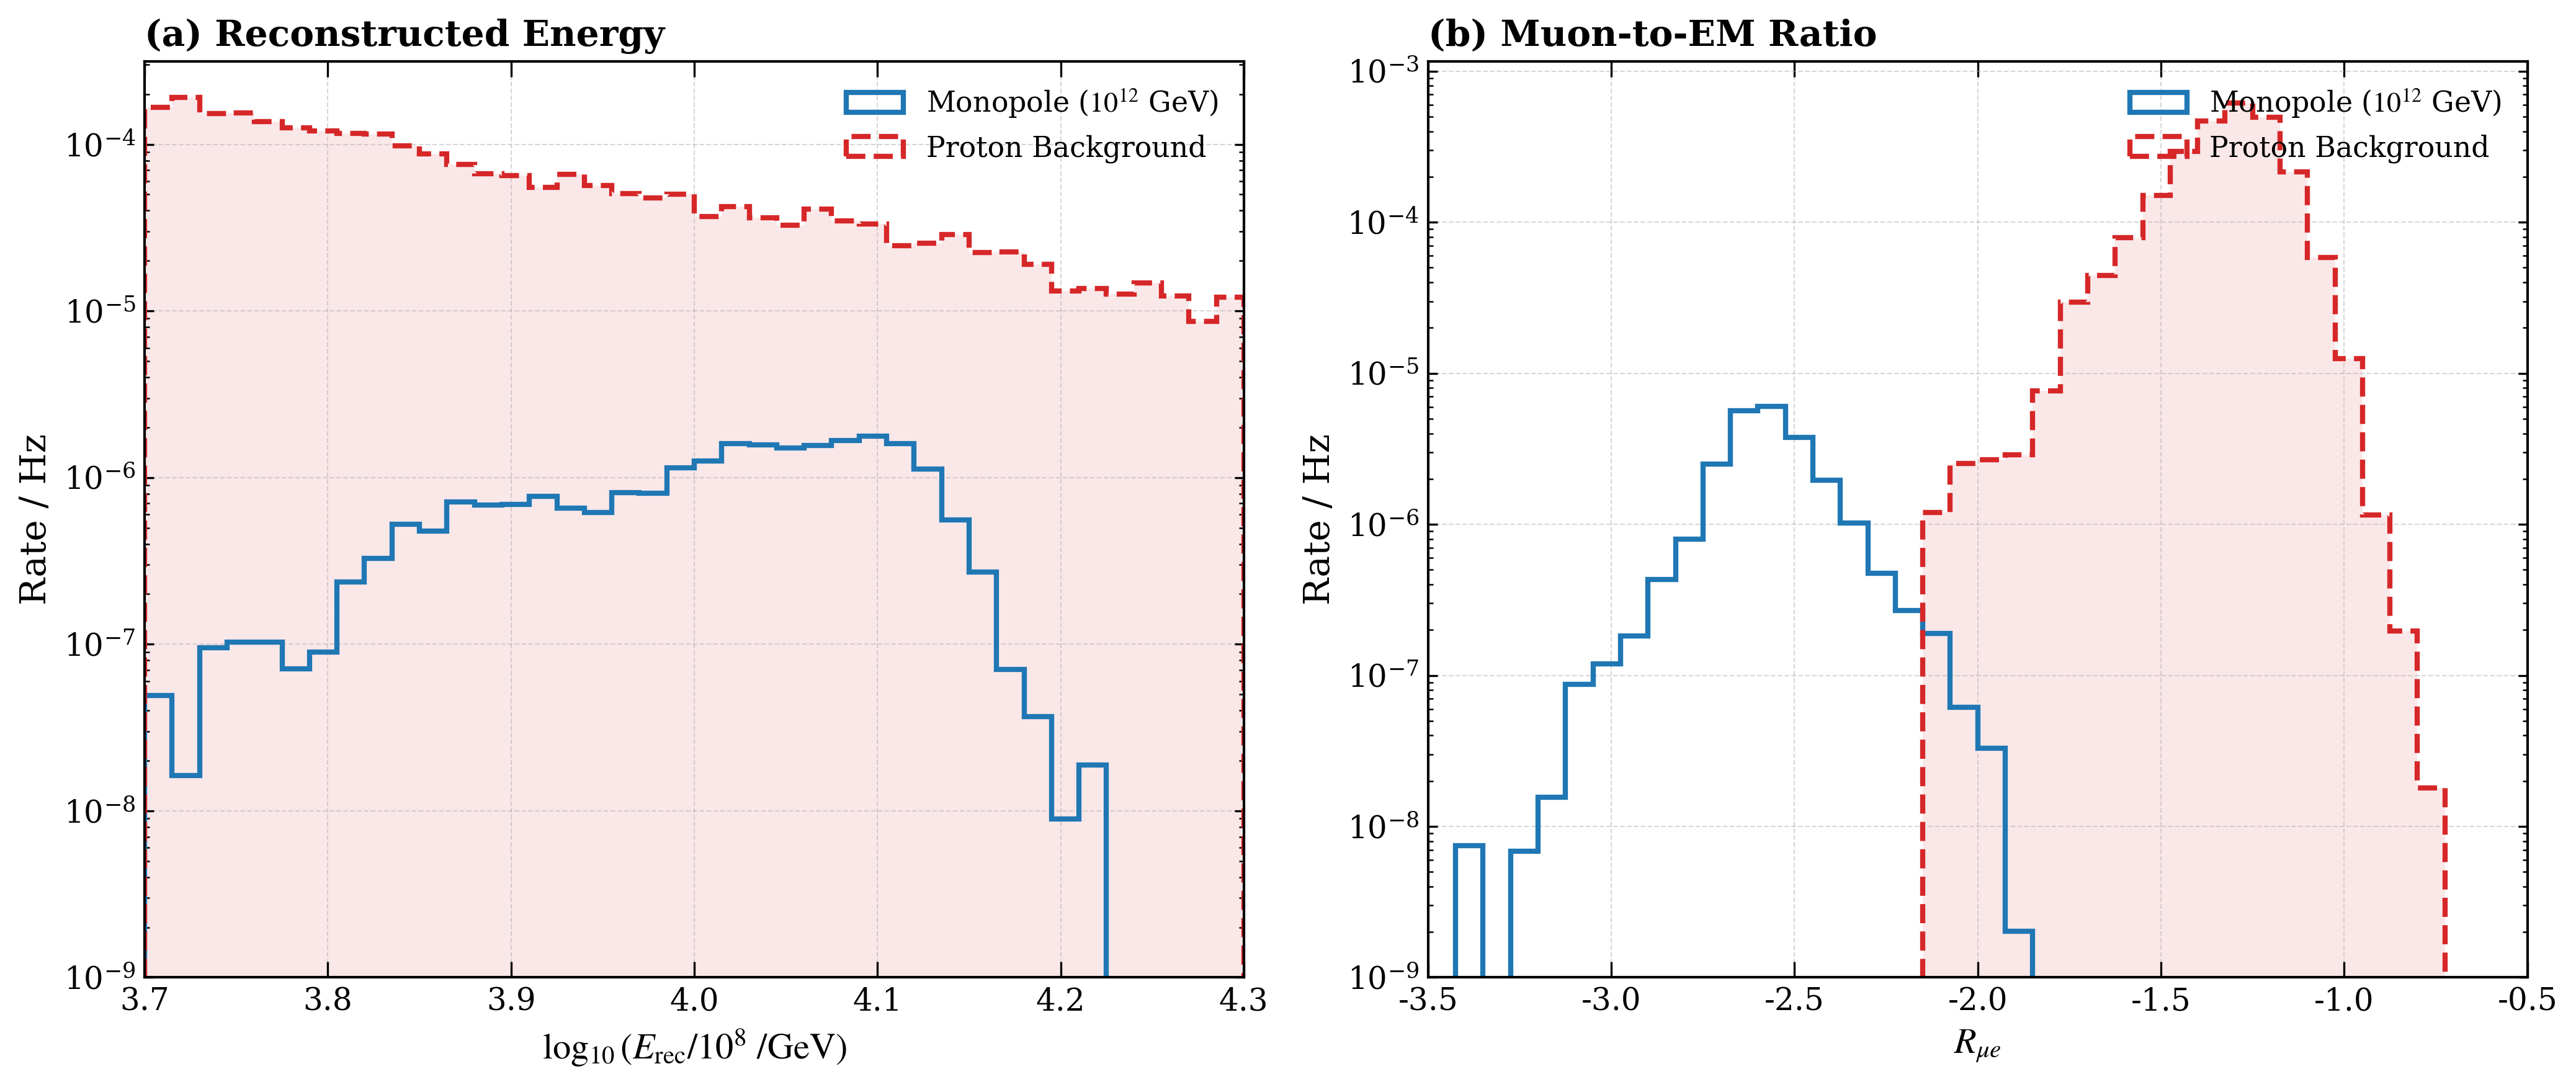

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_formal_recE_Rue(df_list: dict, bins=60, figsize=(14, 6)):
    """
    专门绘制 recE 和 R_ue 的正式对比图，支持权重。
    包含数据类型强制转换和鲁棒的字体设置。
    """
    # 1. 设置学术风格 (兼容 Linux 环境)
    # 如果找不到 Times New Roman，Matplotlib 会回退到 DejaVu Serif，这同样是符合学术标准的衬线体
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.unicode_minus": False,
        "axes.linewidth": 1.0,
        "xtick.major.size": 6,
        "xtick.minor.size": 3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=300)
    
    # 定义配色方案
    colors = ['#1f77b4', '#d62728', 'black', '#2ca02c'] 
    linestyles = ['-', '--', '-.', ':']

    # --- 绘图核心函数 ---
    def plot_variable(ax, param_name, x_range, log_y=False, x_label="", y_label=""):
        for idx, (label, df) in enumerate(df_list.items()):
            # 检查列是否存在
            if param_name not in df.columns:
                print(f"Warning: '{param_name}' not found in dataset '{label}'")
                continue
                
            # --- [修复核心] 强制转换为数值类型 ---
            # errors='coerce' 会将无法转换的字符串变成 NaN，避免 TypeError
            data_series = pd.to_numeric(df[param_name], errors='coerce')
            data = data_series.values
            
            # --- 权重处理 ---
            if 'gaisser_weight' in df.columns:
                w_series = pd.to_numeric(df['gaisser_weight'], errors='coerce')
                weights = w_series.values
            elif 'weight' in df.columns:
                w_series = pd.to_numeric(df['weight'], errors='coerce')
                weights = w_series.values
            else:
                weights = np.ones_like(data)

            # --- 数据清洗 (去 NaN) ---
            # 现在的 data 和 weights 都是 float 类型，np.isnan 可以正常工作了
            mask = ~np.isnan(data) & ~np.isnan(weights)
            
            # 额外过滤：只保留在 x_range 范围内的数据（可选，但推荐，防止极值破坏密度计算）
            if x_range:
                mask &= (data >= x_range[0]) & (data <= x_range[1])

            clean_data = data[mask]
            clean_weights = weights[mask]

            # 防止空数据报错
            if len(clean_data) == 0:
                print(f"Warning: No valid data for '{label}' in range {x_range}")
                continue

            # 计算加权直方图
            if param_name == "recE":
                counts, bin_edges = np.histogram(
                    clean_data, bins=bins, range=x_range, weights=clean_weights, density=False
                )
            elif param_name == "R_ue":
                counts, bin_edges = np.histogram(
                    clean_data, bins=bins, range=x_range, weights=clean_weights,
                )
            
            # 构造阶梯图数据
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            c = colors[idx % len(colors)]
            ls = linestyles[idx % len(linestyles)]
            
            # 绘制 Step 线
            ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='step',
                    label=label, color=c, linewidth=2, linestyle=ls)
            
            # 填充效果
            if 'exp' in label.lower() or 'background' in label.lower():
                 ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='stepfilled',
                    color=c, alpha=0.1)

        # 轴修饰
        ax.set_xlabel(x_label, fontsize=14)
        ax.set_ylabel(y_label, fontsize=14)
        
        if x_range:
            ax.set_xlim(x_range)
        
        if log_y:
            ax.set_yscale('log')
            ax.set_ylim(bottom=1e-9) 
            
        ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.legend(frameon=False, fontsize=11, loc='upper right')

    # --- 2. 绘制 recE (重建能量) ---
    plot_variable(
        ax1, 
        param_name="recE", 
        x_range=(3.7, 4.3), 
        log_y=True, 
        x_label=r"$\log_{10}(E_{\mathrm{rec}}{/10^{8}} ~/ \mathrm{GeV})$",
        y_label="Rate / Hz"
    )
    ax1.set_title("(a) Reconstructed Energy", loc='left', fontweight='bold', fontsize=14)

    # --- 3. 绘制 R_ue (μ/e 比率) ---
    plot_variable(
        ax2, 
        param_name="R_ue", 
        x_range=(-3.5, -0.5), 
        log_y=True, 
        x_label=r"$R_{\mu e}$",
        y_label="Rate / Hz"
    )
    ax2.set_title("(b) Muon-to-EM Ratio", loc='left', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_energy_rue_KeyParams_cut.pdf", bbox_inches='tight')
    plt.show()

SR_Emin = 3.95
SR_Emax = 4.15

df_list = {
    "Monopole ($10^{12}$ GeV)": mn_df_large,
    "Proton Background": pr_df_large,
    # "Experimental Data": exp_full_rue_df,
}

plot_formal_recE_Rue(df_list, bins=40)



signal SR events: 4035, expected events: 2851.3466066871333


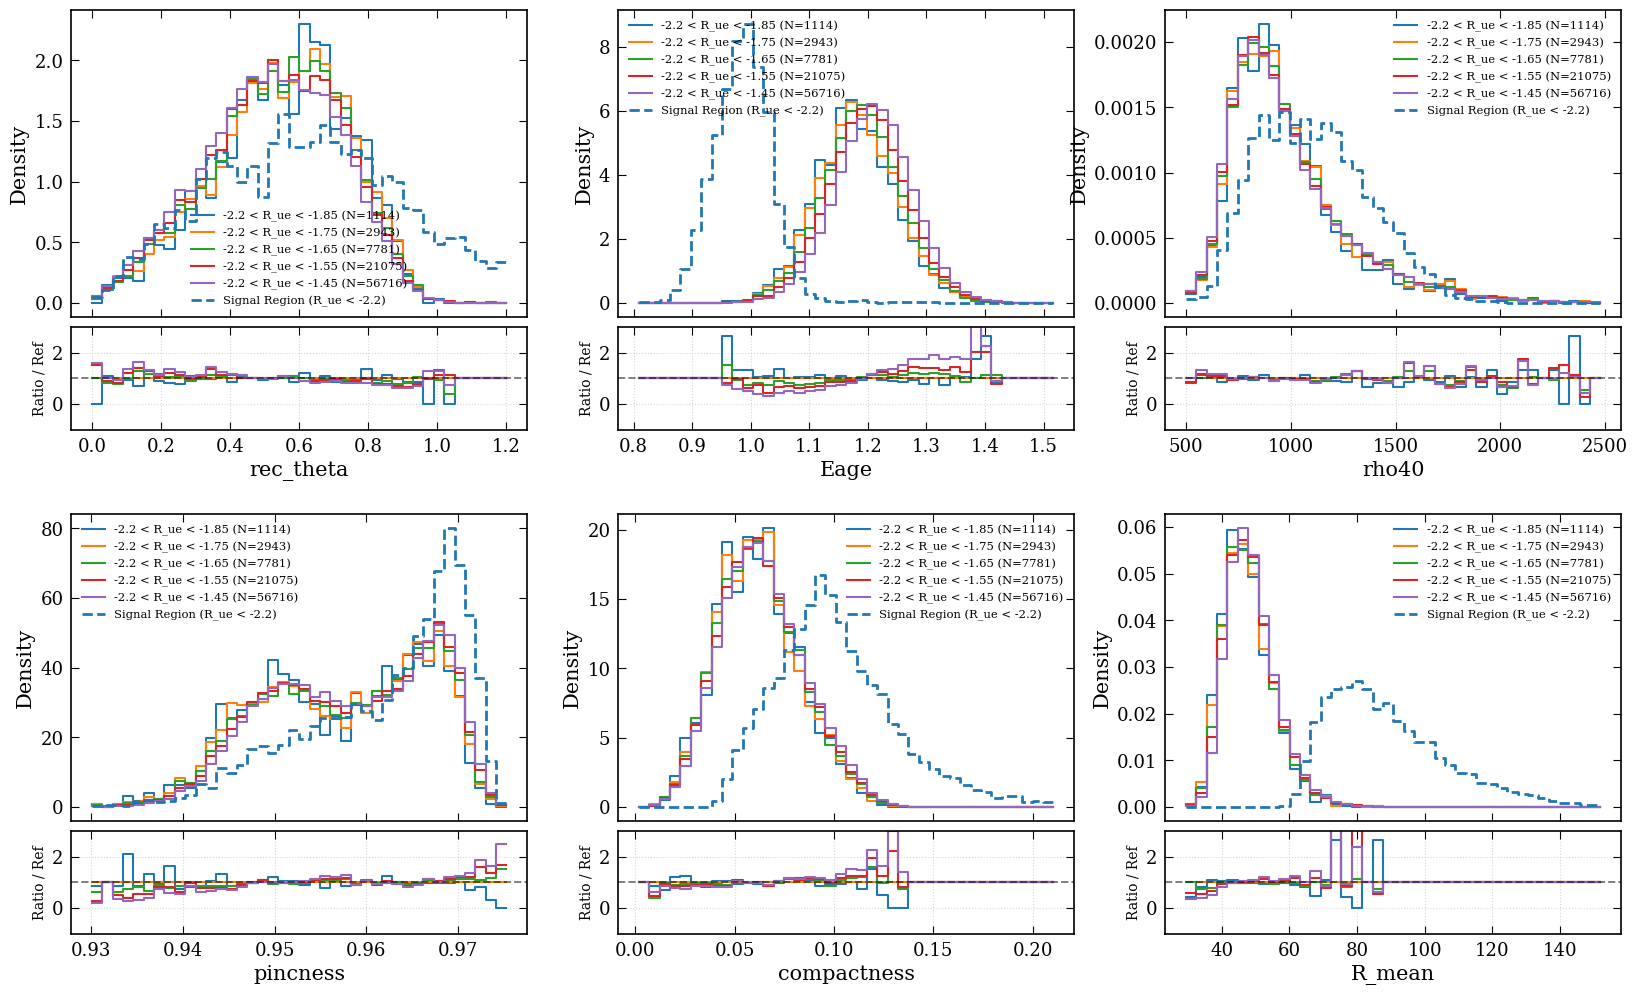

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec

# 强烈建议将 sig_df 和 SR_Rue_cut 作为参数传入，避免函数依赖全局变量
def plot_stability_with_ratio(df, sig_df, SR_Rue_cut, sideband_thresholds=[-1.7, -1.6, -1.5, -1.4, -1.3], 
                              SR_limit=-2.2, reference_thresh=-1.5):
    features = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness', 'R_mean']
    
    # 创建画布
    fig = plt.figure(figsize=(20, 12))
    outer_grid = gridspec.GridSpec(2, 3, fig, wspace=0.2, hspace=0.2)
    colors = sns.color_palette("tab10", len(sideband_thresholds))
    
    # 参考区间的 Mask (Nominal)
    ref_mask = (df['R_ue'] <= reference_thresh) & (df['R_ue'] > SR_limit)
    
    for i, col in enumerate(features):
        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], 
                                                      height_ratios=[3, 1], hspace=0.05)
        
        ax_main = plt.Subplot(fig, inner_grid[0])
        ax_ratio = plt.Subplot(fig, inner_grid[1], sharex=ax_main)
        fig.add_subplot(ax_main)
        fig.add_subplot(ax_ratio)
        
        # --- 1. 数据准备与全局 98% Range 计算 ---
        # 安全提取信号数据及其权重，确保长度严格一致
        valid_sig = sig_df[[col, 'weight']].dropna()
        data_sig = valid_sig[col]
        weights_sig = valid_sig['weight']
        
        # 背景全局数据
        data_bkg_full = df[col].dropna()
        
        # 拼接信号和背景，计算全局 1% 和 99% 分位数 (Middle 98%)
        combined_data = np.concatenate([data_sig.values, data_bkg_full.values])
        vmin = np.percentile(combined_data, 0.)
        vmax = np.percentile(combined_data, 99.99)
        
        # 防止极端情况下（如全零数组）分位数重合
        if vmin == vmax:
            vmin, vmax = combined_data.min(), combined_data.max()
            
        # 统一生成 40 个 bin 的边界 (41个端点)
        bin_edges = np.linspace(vmin, vmax, 41)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # --- 2. 计算基准背景和信号的直方图 ---
        data_ref = df[ref_mask][col].dropna()
        
        # 注意这里传入了自定义的 bin_edges
        counts_sig, _ = np.histogram(data_sig, bins=bin_edges, density=True, weights=weights_sig)
        counts_ref, _ = np.histogram(data_ref, bins=bin_edges, density=True)
        
        # --- 3. 循环绘制不同 Threshold (Background Variations) ---
        for j, thresh in enumerate(sideband_thresholds):
            mask_sub = (df['R_ue'] <= thresh) & (df['R_ue'] > SR_limit)
            data_sub = df[mask_sub][col].dropna()
            
            if len(data_sub) < 10: continue
            
            counts_sub, _ = np.histogram(data_sub, bins=bin_edges, density=True)
            
            # 上方主图: Density
            ax_main.step(bin_edges, np.append(counts_sub, counts_sub[-1]), where='post', 
                         color=colors[j], lw=1.5, label=f"{SR_limit} < R_ue < {thresh} (N={len(data_sub)})")
            
            # 下方副图: Ratio (处理除零)
            ratio = np.divide(counts_sub, counts_ref, out=np.ones_like(counts_sub), where=counts_ref!=0)
            ax_ratio.step(bin_edges, np.append(ratio, ratio[-1]), where='post', color=colors[j], lw=1.5)

        # --- 4. 图表装饰 ---
        # 绘制 Signal Region 参考线
        ax_main.step(bin_edges, np.append(counts_sig, counts_sig[-1]), where='post', 
                      lw=2, label=f"Signal Region (R_ue < {SR_Rue_cut})", linestyle='--')
        
        ax_main.set_ylabel("Density")
        ax_main.legend(fontsize='x-small', loc='best', frameon=False)
        plt.setp(ax_main.get_xticklabels(), visible=False) 
        
        ax_ratio.axhline(1.0, color='black', linestyle='--', alpha=0.5)
        ax_ratio.set_ylim(-1, 3) 
        ax_ratio.set_ylabel("Ratio / Ref", fontsize=10)
        ax_ratio.set_xlabel(col)
        ax_ratio.grid(True, which='both', linestyle=':', alpha=0.5)

    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_Rue_cut_stability.pdf", dpi=300)
    plt.show()

# ==================== 调用部分 ====================
SR_Rue_cut = -2.2
SR_recE_low = 3.75
SR_recE_high = 4.2
reference_thresh = -1.75
sideband_thresholds = [-1.85, -1.75, -1.65, -1.55, -1.45,]

sig_SR_df = mn_df_large[(mn_df_large['R_ue'] < SR_Rue_cut) & (mn_df_large['recE'] > SR_recE_low) & (mn_df_large['recE'] < SR_recE_high)]
print(f"signal SR events: {len(sig_SR_df)}, expected events: {sig_SR_df['weight'].sum()*1437.81*86400}")
exp_muon_Rue_df_large_recE = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > SR_recE_low) & (exp_muon_Rue_df_large['recE'] < SR_recE_high)]

# 将 sig_df 和 SR_Rue_cut 作为参数传入，使函数更健壮
plot_stability_with_ratio(
    df=exp_muon_Rue_df_large_recE, 
    sig_df=sig_SR_df, 
    SR_Rue_cut=SR_Rue_cut,
    sideband_thresholds=sideband_thresholds, 
    SR_limit=SR_Rue_cut, 
    reference_thresh=reference_thresh
)

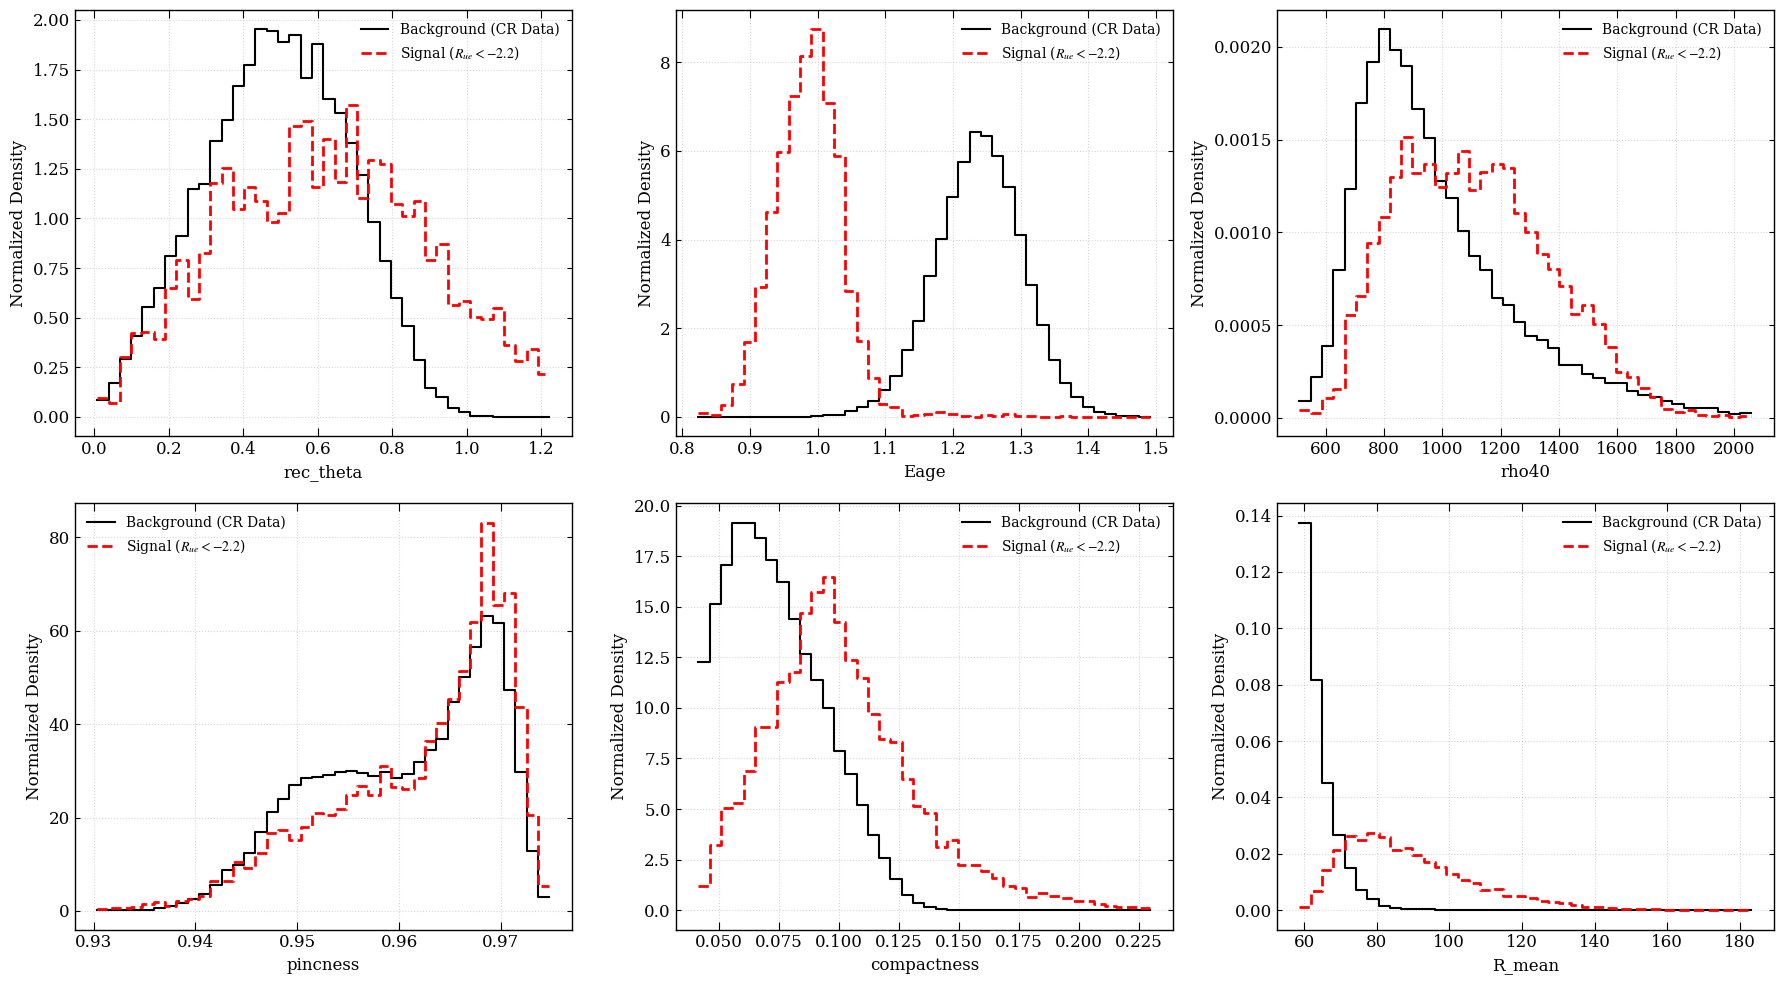

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_signal_vs_background(bkg_df, sig_df, bkg_label="Background", sig_label="Signal"):
    features = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness', 'R_mean']
    
    # 简单的 2行 3列 画布布局
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten() # 展平一维数组方便循环
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # 提取当前特征数据并剔除 NaN
        data_bkg = bkg_df[col].dropna()
        data_sig = sig_df[col].dropna()
        
        # 为了保证信号和背景在同一个 x 轴范围内，取两者的全局最大最小值来划分 bins
        min_val = min(data_bkg.min(), data_sig.min())
        max_val = max(data_bkg.max(), data_sig.max())
        min_val = data_sig.min() ; max_val = data_sig.max() # 以信号的范围为主，避免背景过宽导致信号细节丢失
        
        # 计算 Density 直方图
        counts_bkg, bin_edges = np.histogram(data_bkg, bins=40, range=(min_val, max_val), density=True)
        counts_sig, _ = np.histogram(data_sig, bins=bin_edges, density=True, weights=sig_df['weight'].dropna())
        
        # --- 1. 绘制 Background (实线, 黑色) ---
        ax.step(bin_edges, np.append(counts_bkg, counts_bkg[-1]), where='post', 
                color='black', lw=1.5, label=f"{bkg_label}")
        
        # Optional: 如果想让背景稍微有一点阴影，可以解除下面这行的注释
        # ax.fill_between(bin_edges, np.append(counts_bkg, counts_bkg[-1]), step='post', color='black', alpha=0.1)
        
        # --- 2. 绘制 Signal (虚线, 红色) ---
        ax.step(bin_edges, np.append(counts_sig, counts_sig[-1]), where='post', 
                color='red', lw=2, linestyle='--', label=f"{sig_label}")
        
        # --- 图表装饰 ---
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel("Normalized Density", fontsize=12)
        
        # 也可以开启 log 坐标轴，如果某些特征的长尾效应太明显
        # ax.set_yscale('log') 
        
        ax.legend(fontsize=10, loc='best', frameon=False)
        ax.grid(True, which='both', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_parameter_display.pdf", dpi=300)
    plt.show()

# ================= 调用部分 =================
# 准备信号和背景的 DataFrame

# 这里的背景数据不再根据 threshold 细分，直接使用你指定的 DataFrame
exp_muon_Rue_df_large_recE = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > SR_recE_low) & (exp_muon_Rue_df_large['recE'] < SR_recE_high)]

# 调用函数画图
plot_signal_vs_background(
    bkg_df=exp_muon_Rue_df_large_recE, 
    sig_df=sig_SR_df,
    bkg_label="Background (CR Data)", 
    sig_label=f"Signal ($R_{{ue}} < {SR_Rue_cut}$)" 
)
sig_SR_df = mn_df_large[(mn_df_large['R_ue'] < SR_Rue_cut) & (mn_df_large['recE'] > SR_recE_low) & (mn_df_large['recE'] < SR_recE_high)]


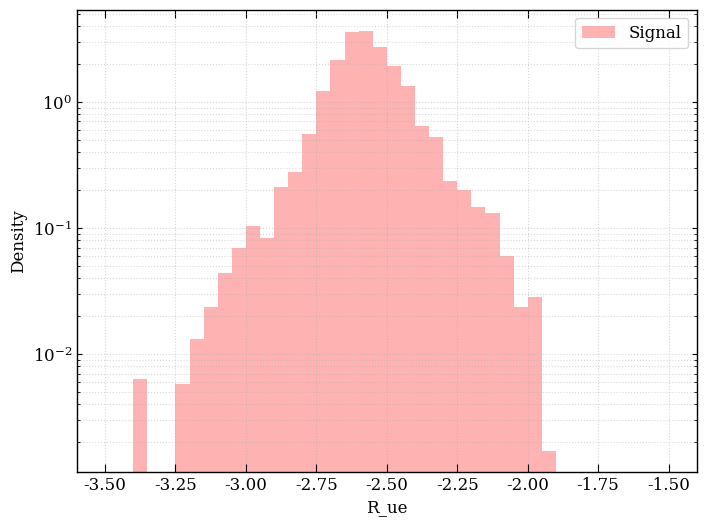

In [45]:
bkg_ = exp_muon_Rue_df_large_recE[(exp_muon_Rue_df_large_recE['R_ue']>-2.85) & (exp_muon_Rue_df_large_recE['R_ue']<-2.7)]

R_ue_range = (-3.5, -1.5)
# only sig
sig_SR_df_Rue = mn_df_large[(mn_df_large['recE'] > SR_recE_low) & (mn_df_large['recE'] < SR_recE_high)]
plt.figure(figsize=(8, 6))
plt.hist(sig_SR_df_Rue['R_ue'], bins=40, weights=sig_SR_df_Rue['weight'], range=R_ue_range, density=True, histtype='stepfilled', label='Signal', color='red', alpha=0.3)
plt.xlabel('R_ue')
plt.ylabel('Density')
# plt.title('R_ue Distribution in SR')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.5)
# plt.xticks(np.arange(-3.5, 0.5, 1))
plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_Rue_SR.pdf", dpi=300)
plt.show()


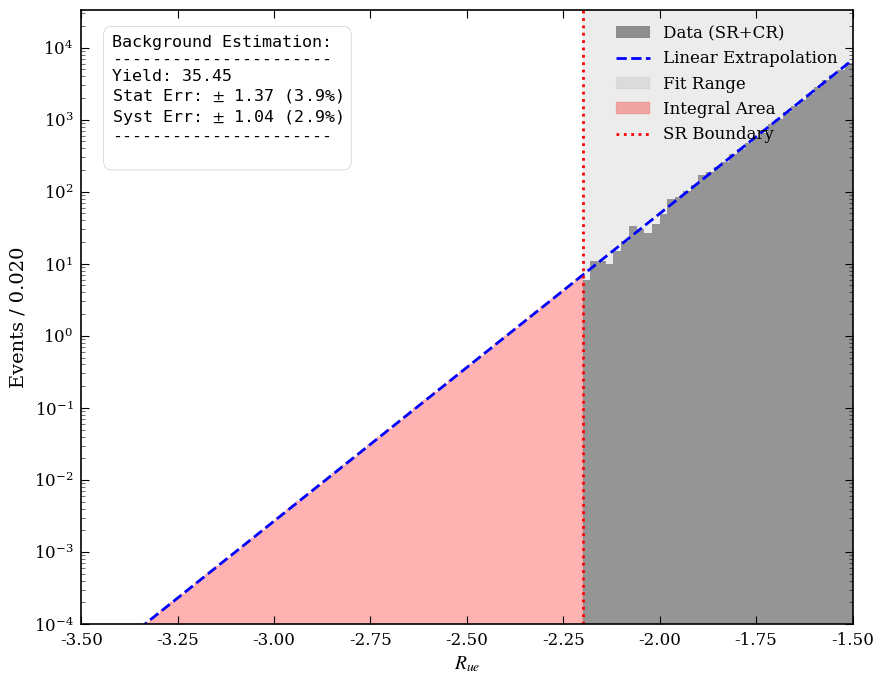

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def calculate_yield(cutoff, a, b, lower_bound=-5.0):
    """解析法计算有限区间 [-5.0, cutoff] 内的积分产额"""
    return (10**(a * cutoff + b) - 10**(a * lower_bound + b)) / (a * np.log(10))

def perform_fit_and_errors(df, sr_threshold=-2.85, fit_range=(-2.85, -2.2), bins=200, lower_bound=-5.0):
    """核心拟合与误差计算模块"""
    # 强制转换为 float 避免 object 数组带来的坑
    counts, bin_edges = np.histogram(df['R_ue'], bins=bins, range=(lower_bound, -1.5), weights=df['weight'])
    counts = counts.astype(float) 
    
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    
    # 过滤拟合区间并剔除 0 计数以避免 log(0)
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1]) & (counts > 0)
    x_fit = bin_centers[fit_mask]
    y_fit = np.log10(counts[fit_mask] / bin_width)
    y_err = 1.0 / (np.sqrt(counts[fit_mask]) * np.log(10)) 

    def linear_func(x, a_val, b_val): 
        return a_val * x + b_val
    
    popt, pcov = curve_fit(linear_func, x_fit, y_fit, sigma=y_err, absolute_sigma=True)
    central_yield = calculate_yield(sr_threshold, *popt, lower_bound=lower_bound)
    
    # --- 统计误差 (Multivariate Normal Sampling) ---
    samples = np.random.multivariate_normal(popt, pcov, 2000)
    stats_yields = [calculate_yield(sr_threshold, s[0], s[1], lower_bound) for s in samples]
    stat_err = np.std(stats_yields)

    # --- 系统误差 (Fit Range Variation) ---
    size_x = len(x_fit)
    size_shift = max(1, int(size_x * 0.2)) # 至少移动 1 个 bin
    
    # 左移/右移拟合区间进行稳定性测试
    popt_var1, _ = curve_fit(linear_func, x_fit[:-size_shift], y_fit[:-size_shift], sigma=y_err[:-size_shift])
    popt_var2, _ = curve_fit(linear_func, x_fit[size_shift:], y_fit[size_shift:], sigma=y_err[size_shift:])
    
    yield_var1 = calculate_yield(sr_threshold, *popt_var1, lower_bound)
    yield_var2 = calculate_yield(sr_threshold, *popt_var2, lower_bound)
    syst_err = np.abs(yield_var1 - yield_var2) / 2.0
    
    return central_yield, stat_err, syst_err, popt, bin_width

def plot_refined_sideband(df_main, sr_threshold=-2.85, fit_range=(-2.85, -2.2), bins=200, lower_bound=-5.0):
    """集成计算、验证与绘图的完整分析函数"""
    
    # 1. 计算主信号区产额及误差
    sr_yield, sr_stat, sr_syst, popt, bin_width = perform_fit_and_errors(
        df_main, sr_threshold, fit_range, bins, lower_bound
    )
    
    # 2. 计算验证区 (Validation Region) 的 Gap
    # 实际产额
    # val_actual = df_val[(df_val['R_ue'] < sr_threshold) & (df_val['R_ue'] > lower_bound)]['weight_norm'].sum()
    # # 拟合外推产额
    # val_pred, _, _, _, _ = perform_fit_and_errors(
    #     df_val, sr_threshold, fit_range, bins, lower_bound
    # )
    # val_gap = np.abs(val_pred - val_actual) / val_pred if val_pred > 0 else 0

    # 3. 开始绘图 (仅使用 R_ue > -5 的数据)
    df_plot = df_main[(df_main['R_ue'] > lower_bound) & (df_main['R_ue'] < -1.5)]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    
    # 画数据直方图
    counts, bin_edges, _ = ax.hist(df_plot[df_plot['R_ue']>SR_Rue_cut]['R_ue'], bins=bins, range=(lower_bound, -1.5), 
                                   weights=df_plot[df_plot['R_ue']>SR_Rue_cut]['weight'], color='black', alpha=0.4, 
                                   histtype='stepfilled', label='Data (SR+CR)')
    
    # 画拟合延伸线
    x_line = np.linspace(lower_bound, fit_range[1], 200)
    y_line = 10**(popt[0] * x_line + popt[1]) * bin_width
    ax.plot(x_line, y_line, color='blue', linestyle='--', linewidth=2, label='Linear Extrapolation')
    
    # 【新增】画拟合区间的背景阴影带
    ax.axvspan(fit_range[0], fit_range[1], color='gray', alpha=0.15, label='Fit Range')
    
    # 【新增】画积分区域的填充 (从 lower_bound 到 cut)
    x_fill = np.linspace(lower_bound, sr_threshold, 100)
    y_fill = 10**(popt[0] * x_fill + popt[1]) * bin_width
    # y2 参数设为一个极小值，以在 Log 坐标轴下正确向下填充
    ax.fill_between(x_fill, 1e-10, y_fill, color='red', alpha=0.3, step='mid', label='Integral Area')
    
    # 分界线
    ax.axvline(sr_threshold, color='red', linestyle=':', linewidth=2, label='SR Boundary')
    
    # 图表修饰
    ax.set_yscale('log')
    # 根据实际数据的量级动态调整 Y 轴底线，防止由于极小值导致画面比例失调
    ax.set_ylim(bottom=max(1e-4, (10**(popt[0] * lower_bound + popt[1]) * bin_width) * 0.1))
    ax.set_xlim(lower_bound, -1.5)
    
    ax.set_xlabel(r'$R_{ue}$', fontsize=14)
    ax.set_ylabel(f'Events / {(bin_edges[1]-bin_edges[0]):.3f}', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.legend(loc='upper right', frameon=False, fontsize=12)
    
    # 【新增】将计算结果作为内嵌文字展示，而不是 Title
    text_info = (
        f"Background Estimation:\n"
        f"----------------------\n"
        f"Yield: {sr_yield:.2f}\n"
        f"Stat Err: $\pm$ {sr_stat:.2f} ({(sr_stat/sr_yield):.1%})\n"
        f"Syst Err: $\pm$ {sr_syst:.2f} ({(sr_syst/sr_yield):.1%})\n"
        f"----------------------\n"
        # f"Validation Gap: {val_gap:.1%}"
    )
    
    # 放置在图表左上角
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.04, 0.96, text_info, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props, fontfamily='monospace')
    
    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_Rue_cut_sideband_fit_less_muon.pdf", dpi=300)
    plt.show()
    
    return sr_yield, sr_stat, sr_syst,
# ================= 调用部分 =================

# 设定物理边界参数
SR_RUE_CUT = SR_Rue_cut
FIT_RANGE = (SR_Rue_cut, -1.5)
LOWER_BOUND = -3.5

# 提取 Validation 区间数据
exp_temp_df_CRrecE = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > SR_recE_low) & (exp_muon_Rue_df_large['recE'] < SR_recE_high)]
sr_yield, sr_stat, sr_syst,  = plot_refined_sideband(
    df_main=exp_temp_df_CRrecE, 
    # df_val=exp_temp_df_CRrecE_lowE,
    sr_threshold=SR_RUE_CUT, 
    fit_range=FIT_RANGE, 
    bins=100, 
    lower_bound=LOWER_BOUND
)

N_lessMuon = sr_yield


In [76]:

def apply_analysis_cuts(df, Rue_cut, re_weight=False, weights_col='weight', dataset_name="Dataset", sig_exp=False):
    cond_E = (df['recE'] > SR_recE_low) & (df['recE'] < SR_recE_high)
    cond_Rue = (df['R_ue'] < Rue_cut) & (df['R_ue'] > SR_limit) if not sig_exp else (df['R_ue'] < SR_limit)
    mask = cond_E & cond_Rue
    df_cut = df[mask].copy()
    if re_weight:
        df_cut[weights_col] = df_cut[weights_col] / df_cut[weights_col].sum() * bkg_yields
        
    print(f"{dataset_name}: after cuts, yield = {df_cut[weights_col].sum():.2f} (N={len(df_cut)})")
    return df_cut


SR_limit=SR_Rue_cut
TIME_SCALE = 1438.81 / 365
bkg_yields = (N_lessMuon) #* TIME_SCALE
bkg_nominal = apply_analysis_cuts(exp_muon_Rue_df_large, reference_thresh, re_weight=True, weights_col='weight', dataset_name="Bkg_Nominal")

bkg_variations = []
for thresh in sideband_thresholds:
    if thresh == reference_thresh:
        continue
    bkg_var = apply_analysis_cuts(exp_muon_Rue_df_large, thresh, re_weight=True, weights_col='weight', dataset_name=f"Bkg_Var_Rue_{thresh:.2f}")
    bkg_var['weight'] = bkg_var['weight'] #* (bkg_yields / bkg_var['weight'].sum())
    bkg_variations.append(bkg_var)

sig_nominal = apply_analysis_cuts(mn_df_large, SR_limit, re_weight=False, weights_col='weight', dataset_name="Sig_Nominal", sig_exp=True)
exp_data = apply_analysis_cuts(exp_muon_Rue_df_large, SR_limit, re_weight=False, weights_col='weight', dataset_name="Exp_Data", sig_exp=True)



# 估计信号MC与真实的差异
# 通过全组分,另一个模型背景与数据的差异应用到sig上
recE_shift = 0.0105
R_ue_shift = 0.0129
def apply_shift_cut_sig(df, recE_shift, Rue_shift):
    mask = (df['recE'] > SR_recE_low + recE_shift) & (df['recE'] < SR_recE_high + recE_shift) & \
           (df['R_ue'] < SR_limit + Rue_shift)
    return df[mask].copy()
sig_recE_shifted_up = apply_shift_cut_sig(sig_nominal, recE_shift, 0)
sig_recE_shifted_down = apply_shift_cut_sig(sig_nominal, -recE_shift, 0)
sig_Rue_shifted_up = apply_shift_cut_sig(sig_nominal, 0, R_ue_shift)
sig_Rue_shifted_down = apply_shift_cut_sig(sig_nominal, 0, -R_ue_shift)

sig_variations = {
    'recE_up': sig_recE_shifted_up,
    'recE_down': sig_recE_shifted_down,
    'R_ue_up': sig_Rue_shifted_up,
    'R_ue_down': sig_Rue_shifted_down
}

# 计算每个变体的预期信号事件数
def calculate_expected_signal(df):
    return df['weight'].sum()
sig_nominal_yield = calculate_expected_signal(sig_nominal)
sig_recE_up_yield = calculate_expected_signal(sig_recE_shifted_up)
sig_recE_down_yield = calculate_expected_signal(sig_recE_shifted_down)
sig_Rue_up_yield = calculate_expected_signal(sig_Rue_shifted_up)
sig_Rue_down_yield = calculate_expected_signal(sig_Rue_shifted_down)


print(f"Signal Nominal Yield: {sig_nominal_yield:.4e}")
print(f"Signal RecE Shifted Up Yield: {sig_recE_up_yield:.4e}, Percent Change: {(sig_recE_up_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal RecE Shifted Down Yield: {sig_recE_down_yield:.4e}, Percent Change: {(sig_recE_down_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal R_ue Shifted Up Yield: {sig_Rue_up_yield:.4e}, Percent Change: {(sig_Rue_up_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal R_ue Shifted Down Yield: {sig_Rue_down_yield:.4e}, Percent Change: {(sig_Rue_down_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")

sig_recE_sys_percent = max(abs((sig_recE_up_yield - sig_nominal_yield) / sig_nominal_yield), abs((sig_recE_down_yield - sig_nominal_yield) / sig_nominal_yield))
sig_Rue_sys_percent = max(abs((sig_Rue_up_yield - sig_nominal_yield) / sig_nominal_yield), abs((sig_Rue_down_yield - sig_nominal_yield) / sig_nominal_yield))
print(f"Estimated Signal Systematic Uncertainty from RecE Shift: {sig_recE_sys_percent:.4%}")
print(f"Estimated Signal Systematic Uncertainty from R_ue Shift: {sig_Rue_sys_percent:.4%}")

Bkg_Nominal: after cuts, yield = 35.45 (N=2943)
Bkg_Var_Rue_-1.85: after cuts, yield = 35.45 (N=1114)
Bkg_Var_Rue_-1.65: after cuts, yield = 35.45 (N=7781)
Bkg_Var_Rue_-1.55: after cuts, yield = 35.45 (N=21075)
Bkg_Var_Rue_-1.45: after cuts, yield = 35.45 (N=56716)
Sig_Nominal: after cuts, yield = 0.00 (N=4035)
Exp_Data: after cuts, yield = 47.00 (N=47)
Signal Nominal Yield: 2.2953e-05
Signal RecE Shifted Up Yield: 2.2865e-05, Percent Change: -0.3834%
Signal RecE Shifted Down Yield: 2.2935e-05, Percent Change: -0.0789%
Signal R_ue Shifted Up Yield: 2.2953e-05, Percent Change: 0.0000%
Signal R_ue Shifted Down Yield: 2.2922e-05, Percent Change: -0.1356%
Estimated Signal Systematic Uncertainty from RecE Shift: 0.3834%
Estimated Signal Systematic Uncertainty from R_ue Shift: 0.1356%


In [73]:
rec_theta_most=np.sqrt(np.cov(sig_nominal["rec_theta"]-sig_nominal["theta"], aweights=sig_nominal["weight"]))
# plt.hist(sig_nominal['rec_theta']-sig_nominal['theta'], bins=100, range=(-0.0250, 0.025), weights=sig_nominal['weight'], alpha=0.5, label='Nominal')
# plt.xlabel('rec_theta')
# plt.ylabel('Frequency')
# plt.title(f'Signal Distribution, std = {rec_theta_most:.4f}')
# plt.legend()
# plt.show()

rec_theta_uncertainty_most=sig_nominal[sig_nominal['rec_theta']>(sig_nominal['rec_theta'].max()-rec_theta_most)]['weight'].sum()/sig_nominal['weight'].sum()
print(f"Estimated Signal Systematic Uncertainty from rec_theta: {rec_theta_uncertainty_most:.4%}")

Estimated Signal Systematic Uncertainty from rec_theta: 0.0176%


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import copy
# ==========================================
# 0. 全局配置
# ==========================================

# 这里的特征必须与 DataFrame 中的列名完全一致
FEATURES = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness','R_mean'] 
TARGET_FLUX = 'weight'

# ==========================================
# 1. 类定义 (保持你的架构，稍作优化)
# ==========================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        # drop_prob 通常在 0.2 到 0.5 之间
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(p=0.5),  # <--- 新增：丢弃50%的神经元连接

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(p=0.5),  # <--- 新增

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

from sklearn.metrics import roc_curve, auc

class ClassifierManager:
    def __init__(self, features, model_type='xgb', device='cpu'):
        self.features = features
        self.model_type = model_type.lower()
        self.device = device
        
        self.trained_models = []
        self.trained_scalers = []
        
        # [新增] 用于存储绘图数据
        self.loss_histories = [] # 存储每个Fold的 {'train': [], 'val': []}
        self.fold_roc_data = []  # 存储每个Fold的 (y_val, preds)
        
    def prepare_data(self, bkg_df, sig_df, weight_col='weight', sig_weight_col='weight'):
        X_bkg = bkg_df[self.features].values
        X_sig = sig_df[self.features].values
        
        w_bkg = bkg_df[weight_col].values
        w_sig = sig_df[sig_weight_col].values
        w_bkg = w_bkg / w_bkg.mean()
        w_sig = w_sig / w_sig.mean()

        self.X_raw = np.vstack([X_bkg, X_sig])
        self.y_raw = np.concatenate([np.zeros(len(X_bkg)), np.ones(len(X_sig))])
        self.w_raw = np.concatenate([w_bkg, w_sig])
        
        self.n_bkg = len(X_bkg)

    def _get_new_model(self):
        if self.model_type == 'xgb':
            return xgb.XGBClassifier(
                n_estimators=800, max_depth=4, learning_rate=0.03,
                objective='binary:logistic', n_jobs=-1, random_state=42,
                tree_method='gpu_hist' if 'cuda' in self.device else 'hist',
                early_stopping_rounds=50
            )
        elif self.model_type == 'mlp':
            return MLP(len(self.features)).to(self.device)

    def train_kfold(self, n_splits=5, epochs=2000):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        oof_preds = np.zeros(len(self.y_raw))
        
        self.trained_models = []
        self.trained_scalers = []
        self.loss_histories = [] # 重置历史
        self.fold_roc_data = []  # 重置ROC数据

        print(f">>> Starting {n_splits}-Fold Cross-Validation ({self.model_type})...")

        for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_raw, self.y_raw)):
            print(f"\n--- Fold {fold+1}/{n_splits} ---")
            
            X_train, y_train, w_train = self.X_raw[train_idx], self.y_raw[train_idx], self.w_raw[train_idx]
            X_val, y_val, w_val = self.X_raw[val_idx], self.y_raw[val_idx], self.w_raw[val_idx]
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            self.trained_scalers.append(scaler)
            
            model = self._get_new_model()
            
            # [新增] 当前Fold的Loss记录
            fold_history = {'train': [], 'val': []}

            if self.model_type == 'xgb':
                model.fit(X_train_scaled, y_train, sample_weight=w_train, eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
                    sample_weight_eval_set=[w_train, w_val],
                    verbose=50 # 关闭详细打印，保持整洁
                )
                # XGBoost 获取 loss history 比较特殊，这里简化处理，只处理 MLP 的需求
                # 如果需要 XGB 的 Loss 图，需要从 model.evals_result() 获取
                try:
                    limit = model.best_iteration + 1
                    preds = model.predict_proba(X_val_scaled, iteration_range=(0, limit))[:, 1]
                except AttributeError:
                    preds = model.predict_proba(X_val_scaled)[:, 1]

            elif self.model_type == 'mlp':
                Xt = torch.FloatTensor(X_train_scaled).to(self.device)
                yt = torch.FloatTensor(y_train).unsqueeze(1).to(self.device)
                wt = torch.FloatTensor(w_train).unsqueeze(1).to(self.device)
                
                Xv = torch.FloatTensor(X_val_scaled).to(self.device)
                yv = torch.FloatTensor(y_val).unsqueeze(1).to(self.device)
                wv = torch.FloatTensor(w_val).unsqueeze(1).to(self.device)
                
                optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
                criterion = nn.BCELoss(reduction='none')
                
                for epoch in range(epochs):
                    model.train()
                    optimizer.zero_grad()
                    out = model(Xt)
                    loss_train = (criterion(out, yt) * wt).mean()
                    loss_train.backward()
                    optimizer.step()
                    
                    # [新增] 每个Epoch都记录验证集 Loss (为了画平滑的曲线)
                    model.eval()
                    with torch.no_grad():
                        out_val = model(Xv)
                        loss_val = (criterion(out_val, yv) * wv).mean()
                    
                    # 记录历史
                    fold_history['train'].append(loss_train.item())
                    fold_history['val'].append(loss_val.item())

                    if (epoch + 1) % 100 == 0:
                        print(f"Epoch [{epoch+1}/{epochs}] | Train: {loss_train.item():.5f} | Val: {loss_val.item():.5f}")

                model.eval()
                with torch.no_grad():
                    preds = model(Xv).cpu().numpy().flatten()
                
                # 记录本折的 Loss 历史
                self.loss_histories.append(fold_history)

            oof_preds[val_idx] = preds
            self.trained_models.append(model)
            # [新增] 记录本折的 ROC 数据
            self.fold_roc_data.append((y_val, preds))
            
        print("\n>>> K-Fold Training Complete.")
        return oof_preds

    def predict_ensemble(self, df):
        df_clean = df[self.features].copy()
        for col in self.features:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        df_clean = df_clean.fillna(0).infer_objects()
        X_raw = df_clean.values
        
        all_fold_preds = []
        for i, (model, scaler) in enumerate(zip(self.trained_models, self.trained_scalers)):
            X_scaled = scaler.transform(X_raw)
            if self.model_type == 'xgb':
                try:
                    if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                        limit = model.best_iteration + 1
                        p = model.predict_proba(X_scaled, iteration_range=(0, limit))[:, 1]
                    else:
                        p = model.predict_proba(X_scaled)[:, 1]
                except:
                    p = model.predict_proba(X_scaled)[:, 1]
            elif self.model_type == 'mlp':
                model.eval()
                Xt = torch.FloatTensor(X_scaled).to(self.device)
                with torch.no_grad():
                    p = model(Xt).cpu().numpy().flatten()
            all_fold_preds.append(p)
        return np.mean(all_fold_preds, axis=0)
    
    def get_feature_importance(self):
        if self.model_type == 'xgb' and self.trained_models:
            return dict(zip(self.features, self.trained_models[0].feature_importances_))
        return {}

class Plotter:
    COLORS = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'cyan']
    
    @staticmethod
    def plot_score(dfs, labels, weights, bins=50, title="Score Distribution"):
        # 1. 设置画板：上大下小 (3:1)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                       gridspec_kw={'height_ratios': [3, 1]}, 
                                       sharex=True)
        
        hists = []
        edges = None
        
        # ==========================================
        # 上图：分布直方图 (Main Distribution)
        # ==========================================
        for i, (df, label, w) in enumerate(zip(dfs, labels, weights)):
            # 视觉样式：最后两个(Signal/Exp)用填充，其他的用线条
            is_ref = (i >= len(dfs) - 2) 
            h_type = 'stepfilled' if is_ref else 'step'
            alpha = 0.3 if is_ref else 1.0
            lw = 2 if not is_ref else 1.5
            color = Plotter.COLORS[i % len(Plotter.COLORS)]
            
            # 绘制并保存直方图数据
            # density=True 用于对比形状
            h, bin_edges, _ = ax1.hist(df['mlp_score'], bins=bins, range=(0, 1), weights=w,
                                       histtype=h_type, alpha=alpha, lw=lw, density=True, 
                                       label=label, color=color)
            hists.append(h)
            if edges is None: edges = bin_edges
            
        ax1.set_ylabel('Normalized Density')
        # ax1.set_yscale('log') # 强烈建议 Score 开启 Log 模式，否则看不到高分段细节
        ax1.set_title(title)
        # 图例放上面，避免遮挡数据
        ax1.legend(loc='upper center',  ncol=3, frameon=False)
        ax1.grid(True, which='both', linestyle='--', alpha=0.3)

        # ==========================================
        # 下图：比例图 (Ratio Plot)
        # ==========================================
        # 默认以第一个数据集 (dfs[0], 即 Baseline) 作为分母
        ref_h = hists[0]
        centers = 0.5 * (edges[:-1] + edges[1:])
        
        for i in range(1, len(hists)):
            # 计算 Ratio，处理除零情况
            # 信号 (Signal) 分布通常和背景差异极大，画 Ratio 可能会让图变得很乱
            # 你可以选择跳过 Signal (通常 label 包含 'Signal' 或 'MN')
            if 'Signal' in labels[i] or 'MN' in labels[i]:
                continue

            ratio = np.divide(hists[i], ref_h, out=np.zeros_like(ref_h), where=ref_h!=0)
            
            # 只画有数据的点，避免由 0/0 产生的噪点
            mask = ref_h > 0
            ax2.plot(centers[mask], ratio[mask], 'o-', markersize=3, lw=1,
                     color=Plotter.COLORS[i % len(Plotter.COLORS)])
        
        # 参考线
        ax2.axhline(1, color='gray', linestyle='--')
        
        ax2.set_xlabel('Classification Score (0=Bkg, 1=Sig)')
        ax2.set_ylabel('Ratio / Baseline')
        
        # 设置 Ratio 的显示范围，避免个别极端值破坏视图
        ax2.set_ylim(0.0, 2.0) 
        ax2.grid(True, which='both', linestyle='--', alpha=0.3)
        
        # 调整间距
        plt.subplots_adjust(hspace=0.05)
        plt.show()


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# ==========================================
# 2. 数据准备与 Cut 策略
# ==========================================
print("\n>>> Step A: Applying Physics Cuts...")

# 1. 训练用背景 (使用 Shape Invariant Template: Rue < -1.5)
# 注意：pr_df_large_cut 已经是 Rue < -1.5 了，这里再加 recE cut
print(f"Original Bkg: yield = {bkg_nominal[TARGET_FLUX].sum():.2f} (N={len(bkg_nominal)})")
bkg_nominal_train = bkg_nominal.copy()
# bkg_nominal_train = bkg_nominal_train.sample(10000, random_state=42, replace=False).copy()
# bkg_nominal_train[TARGET_FLUX] *= pr_df_large_cut[TARGET_FLUX].sum() / bkg_nominal_train[TARGET_FLUX].sum()
# bkg_nominal_train = apply_analysis_cuts(bkg_nominal_train, "Bkg Train Final")

# 2. 训练用信号
print(f"Original Signal: yield = {sig_nominal[TARGET_FLUX].sum():.2f} (N={len(sig_nominal)})")
# sig_nominal_train = sig_nominal.sample(4000, random_state=42, replace=False).copy()
# sig_nominal_train['weight'] *= sig_nominal['weight'].sum() / sig_nominal_train['weight'].sum()
sig_nominal_train = sig_nominal
# 3. 实验数据
exp_data = exp_data.copy()

# ==========================================
# 3. K-Fold 训练
# ==========================================
print("\n>>> Step B: K-Fold Training & OOF Prediction...")

# manager = ClassifierManager(FEATURES, model_type='xgb', device='cpu')
manager = ClassifierManager(FEATURES, model_type='mlp', device='cpu')
manager.prepare_data(bkg_nominal_train, sig_nominal_train, weight_col=TARGET_FLUX, sig_weight_col='weight')
oof_scores_total = manager.train_kfold(n_splits=5, epochs=500)

# 将 OOF 分数拆分回 Bkg 和 Sig DataFrame
# 顺序必须和 prepare_data 中的合并顺序一致 (先 Bkg 后 Sig)
n_bkg = manager.n_bkg
bkg_nominal_train['mlp_score'] = oof_scores_total[:n_bkg]
sig_nominal_train['mlp_score'] = oof_scores_total[n_bkg:]

print("OOF Scores assigned back to training dataframes.")

# ==========================================
# 4. 外部数据集成预测 (Ensemble Prediction)
# ==========================================
print("\n>>> Step C: Ensemble Inference on External Data...")
exp_data['mlp_score'] = manager.predict_ensemble(exp_data)
bkg_var_final_list = []
for bkg_var in bkg_variations:
    bkg_var['mlp_score'] = manager.predict_ensemble(bkg_var)
    bkg_var_final_list.append(bkg_var)

sig_var_final_list = []
for sig_var_name, sig_var_df in sig_variations.items():
    sig_var_df['mlp_score'] = manager.predict_ensemble(sig_var_df)
    sig_var_final_list.append(sig_var_df)
# ==========================================
# 5. 结果可视化与检查
# ==========================================
print("\n>>> Step D: Visualizing Results...")

# 输出高分区的统计信息
CUT_SCORE = 0.
n_exp = exp_data[exp_data['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_nominal_train[bkg_nominal_train['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_nominal_train[sig_nominal_train['mlp_score'] > CUT_SCORE]['weight'].sum()

print(f"\n[Check] Events with Score > {CUT_SCORE} (Annualized):")
print(f"  Exp Data: {n_exp:.2f}")
# print(f"  MC Bkg :  {n_bkg*365*86400:.2f}")
print(f"  Signal :  {n_sig*365*86400:.2f}")


# 输出高分区的统计信息
CUT_SCORE = 0.9
n_exp = exp_data[exp_data['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_nominal_train[bkg_nominal_train['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_nominal_train[sig_nominal_train['mlp_score'] > CUT_SCORE]['weight'].sum()

print(f"\n[Check] Events with Score > {CUT_SCORE} (Annualized):")
print(f"  Exp Data: {n_exp:.2f}")
# print(f"  MC Bkg :  {n_bkg*365*86400:.2f}")
print(f"  Signal :  {n_sig*365*86400:.2f}")




>>> Step A: Applying Physics Cuts...
Original Bkg: yield = 35.45 (N=2943)
Original Signal: yield = 0.00 (N=4035)

>>> Step B: K-Fold Training & OOF Prediction...
>>> Starting 5-Fold Cross-Validation (mlp)...

--- Fold 1/5 ---
Epoch [100/500] | Train: 0.04262 | Val: 0.02518
Epoch [200/500] | Train: 0.01691 | Val: 0.01024
Epoch [300/500] | Train: 0.00904 | Val: 0.00606
Epoch [400/500] | Train: 0.00546 | Val: 0.00458
Epoch [500/500] | Train: 0.00414 | Val: 0.00395

--- Fold 2/5 ---
Epoch [100/500] | Train: 0.05088 | Val: 0.02477
Epoch [200/500] | Train: 0.01954 | Val: 0.00714
Epoch [300/500] | Train: 0.01136 | Val: 0.00356
Epoch [400/500] | Train: 0.00713 | Val: 0.00205
Epoch [500/500] | Train: 0.00492 | Val: 0.00160

--- Fold 3/5 ---
Epoch [100/500] | Train: 0.04532 | Val: 0.02288
Epoch [200/500] | Train: 0.01926 | Val: 0.00596
Epoch [300/500] | Train: 0.01090 | Val: 0.00253
Epoch [400/500] | Train: 0.00811 | Val: 0.00133
Epoch [500/500] | Train: 0.00512 | Val: 0.00084

--- Fold 4/5 ---

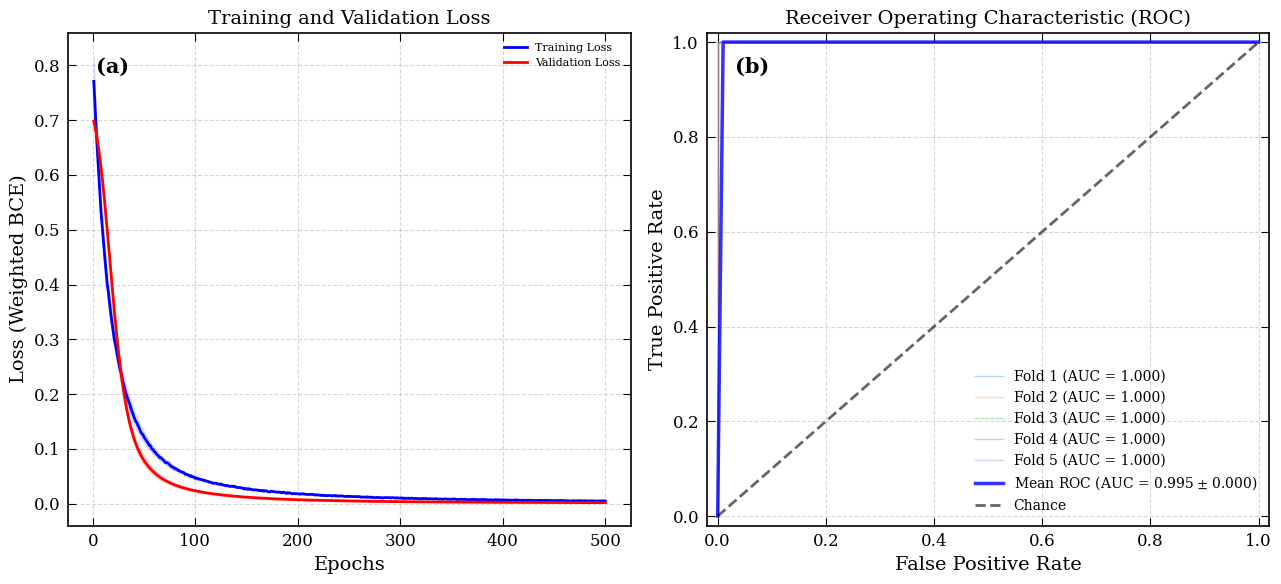

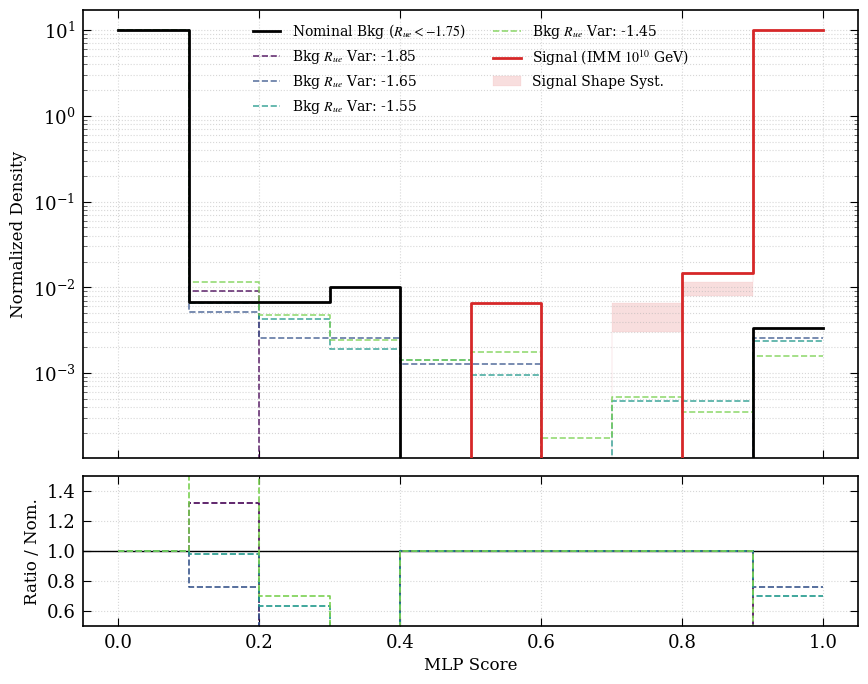

In [78]:


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# 设置全局绘图风格 (可选，如果没有安装 latex 可以注释掉 usetex=True)
def plot_training_evaluation(manager, output_dir="."):
    """
    绘制 Loss 曲线和 ROC 曲线
    """
    # 设置学术风格
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    
    # ==========================================
    # 1. Loss Curve (Mean +/- Std)
    # ==========================================
    ax1 = axes[0]
    if manager.model_type == 'mlp' and manager.loss_histories:
        # 获取所有 fold 的 loss
        train_losses = np.array([h['train'] for h in manager.loss_histories])
        val_losses = np.array([h['val'] for h in manager.loss_histories])
        
        # 计算均值和标准差
        mean_train = np.mean(train_losses, axis=0)
        std_train = np.std(train_losses, axis=0)
        mean_val = np.mean(val_losses, axis=0)
        std_val = np.std(val_losses, axis=0)
        epochs = range(1, len(mean_train) + 1)
        
        # 绘图
        ax1.plot(epochs, mean_train, 'b-', label='Training Loss', lw=2)
        ax1.fill_between(epochs, mean_train - std_train, mean_train + std_train, color='b', alpha=0.15)
        
        ax1.plot(epochs, mean_val, 'r-', label='Validation Loss', lw=2)
        ax1.fill_between(epochs, mean_val - std_val, mean_val + std_val, color='r', alpha=0.15)
        
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss (Weighted BCE)')
        ax1.text(0.05, 0.95, '(a)',  transform=ax1.transAxes, fontsize=15, fontweight='bold', va='top')
        ax1.set_title('Training and Validation Loss')
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.5)
    else:
        ax1.text(0.5, 0.5, 'Loss history available only for MLP', ha='center', transform=ax1.transAxes)

    # ==========================================
    # 2. ROC Curve (K-Fold Mean)
    # ==========================================
    ax2 = axes[1]
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    # 绘制每一折的 ROC
    for i, (y_true, y_score) in enumerate(manager.fold_roc_data):
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        # 插值以便计算平均
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        # 绘制浅色细线
        ax2.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')
        
    # 绘制平均 ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    
    ax2.plot(mean_fpr, mean_tpr, color='b', label=rf'Mean ROC (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})', lw=2.5, alpha=0.8)
    
    # 绘制对角线
    ax2.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', label='Chance', alpha=0.6)
    
    ax2.set_xlim([-0.02, 1.02])
    ax2.set_ylim([-0.02, 1.02])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('Receiver Operating Characteristic (ROC)')
    ax2.text(0.05, 0.95, '(b)',  transform=ax2.transAxes, fontsize=15, fontweight='bold', va='top')
    ax2.legend(loc="lower right", fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    fig.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_model_evaluation_metrics.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    # 如果需要保存
   
plot_training_evaluation(manager)

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# 设置全局绘图风格：Times New Roman 字体，向内的刻度
plt.rcParams.update({
    'font.family': 'serif',
    "font.serif": [ "DejaVu Serif", "serif"],
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,  # 去掉图例边框
    'figure.figsize': (10, 8),
    'axes.linewidth': 1.2     # 边框加粗
})

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

class Plotter:
    # 更加稳重、对比度高的学术配色
    COLORS = {
        'bkg_nom': 'black',      # 基准背景
        'signal':  '#d62728',    # 信号
        'data':    'black'       # 数据点
    }
    
    @staticmethod
    def plot_score(dfs, labels, weights, bins=50, title="MLP Score Distribution"):
        fig = plt.figure(figsize=(10, 8))
        gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.06)
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1], sharex=ax1)

        # 1. 预计算所有直方图 (Density=True 用于形态对比)
        hists = []
        edges = None
        for df, w in zip(dfs, weights):
            h, e = np.histogram(df['mlp_score'], bins=bins, range=(0, 1), weights=w, density=True)
            hists.append(h)
            if edges is None:
                edges = e

        # 2. 自动对输入数据进行分类 (通过 Label 识别 Signal 和 Background)
        idx_bkg_nom = 0
        idx_bkg_vars = []
        idx_sig_nom = -1
        idx_sig_vars = []

        for i, lbl in enumerate(labels):
            if i == 0:
                pass # 第0个默认是基准背景
            elif 'Signal' in lbl or 'sig' in lbl.lower():
                if idx_sig_nom == -1:
                    idx_sig_nom = i     # 碰到的第一个 Signal 设为 Nominal Signal
                else:
                    idx_sig_vars.append(i) # 后续的 Signal 设为 Variations
            else:
                idx_bkg_vars.append(i)  # 剩下的全是 Background Variations

        # 生成背景变分的渐变色
        n_bkg_sys = len(idx_bkg_vars)
        sys_colors = plt.cm.viridis(np.linspace(0, 0.8, n_bkg_sys)) if n_bkg_sys > 0 else []

        # =========================================================
        # 主图 (ax1) 绘制逻辑
        # =========================================================
        
        # A. 画基准背景
        h_bkg_nom = hists[idx_bkg_nom]
        ax1.step(edges, np.append(h_bkg_nom, h_bkg_nom[-1]), where='post', 
                 color=Plotter.COLORS['bkg_nom'], lw=2, zorder=10, label=labels[idx_bkg_nom])
        
        # B. 画背景变分 (虚线)
        for c_idx, i in enumerate(idx_bkg_vars):
            h_var = hists[i]
            ax1.step(edges, np.append(h_var, h_var[-1]), where='post', 
                     color=sys_colors[c_idx], lw=1.2, alpha=0.8, ls='--', label=labels[i])

        # C. 画信号 (基准为实线，变分为阴影包络带)
        if idx_sig_nom != -1:
            h_sig_nom = hists[idx_sig_nom]
            ax1.step(edges, np.append(h_sig_nom, h_sig_nom[-1]), where='post', 
                     color=Plotter.COLORS['signal'], lw=2, zorder=11, label=labels[idx_sig_nom])
            
            # 如果存在信号变分，计算 Min/Max 形成包络线
            if len(idx_sig_vars) > 0:
                sig_var_arrays = np.array([hists[i] for i in idx_sig_vars])
                sig_max = np.max(sig_var_arrays, axis=0)
                sig_min = np.min(sig_var_arrays, axis=0)
                
                # 使用 fill_between 绘制信号的系统误差阴影带 (仅添加一个图例)
                ax1.fill_between(edges, 
                                 np.append(sig_min, sig_min[-1]), 
                                 np.append(sig_max, sig_max[-1]), 
                                 step='post', color=Plotter.COLORS['signal'], 
                                 alpha=0.15, zorder=1, label='Signal Shape Syst.')

        # 主图修饰
        ax1.set_yscale('log')
        ax1.set_ylabel('Normalized Density', fontsize=12)
        ax1.legend(loc='best', ncol=2, fontsize=10, frameon=False)
        ax1.grid(True, which='both', ls=':', alpha=0.5)
        # ax1.set_ylim(1e-3, 15) # 建议手动给一个合理的下限，防止 log 轴底部太杂乱

        # =========================================================
        # Ratio Plot (ax2) 绘制逻辑 - 仅比较背景
        # =========================================================
        ax2.axhline(1, color='black', lw=1, ls='-')
        
        for c_idx, i in enumerate(idx_bkg_vars):
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = hists[i] / h_bkg_nom
                # 把除以 0 产生的 nan 或 inf 设为 1，防止画图崩溃
                ratio = np.nan_to_num(ratio, nan=1.0, posinf=1.0, neginf=1.0)
            
            ax2.step(edges, np.append(ratio, ratio[-1]), where='post', 
                     color=sys_colors[c_idx], lw=1.2, ls='--')

        # Ratio 轴修饰
        ax2.set_ylabel('Ratio / Nom.', fontsize=12)
        ax2.set_xlabel('MLP Score', fontsize=12)
        ax2.set_ylim(0.5, 1.5) 
        ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
        ax2.grid(True, ls=':', alpha=0.5)

        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_score_distribution.pdf", dpi=300, bbox_inches='tight')
        plt.show()
# ==========================================
# 调用部分
# ==========================================
rue_cuts = np.array(sideband_thresholds)
rue_cuts = rue_cuts[rue_cuts != reference_thresh] # 去掉 Nominal 的 cut

dfs_to_plot = [bkg_nominal_train, *bkg_var_final_list, sig_nominal_train, *sig_var_final_list]

# 优化标签：带 "Signal" 关键字的会被自动归为信号组
labels = [
    r'Nominal Bkg ($R_{{ue}} < -1.75$)', 
    *[r'Bkg $R_{{ue}}$ Var: {}'.format(c) for c in rue_cuts[:len(bkg_var_final_list)]],
    r'Signal (IMM $10^{10}$ GeV)',      # <-- 被识别为 Nominal Signal
    r'Signal RecE Shift Up',            # <-- 以下4个被识别为 Signal Vars，用于画阴影
    r'Signal RecE Shift Down',
    r'Signal R_ue Shift Up',
    r'Signal R_ue Shift Down'
]

# 权重逻辑保持不变
weights_to_plot = []
for df in dfs_to_plot:
    if 'mlp_score' in df.columns:
        w_col = 'weight' if 'trueE' in df.columns else TARGET_FLUX
        weights_to_plot.append(df[w_col])

# 调用绘图函数
Plotter.plot_score(dfs_to_plot, labels, weights_to_plot, bins=10, title="LHAASO-KM2A Monopole Search")

Bkg Var Max: [3.54156547e+01 1.36805437e-01 2.40893474e-02]
Bkg Var Min: [3.52865800e+01 3.18199953e-02 1.00000000e-05]
Bkg Nominal: [3.53511174e+01 8.43127160e-02 1.20446737e-02]
Bkg Max Diff: [0.06453739 0.05249272 0.01204467]
sig diff [0.         2.98934994 7.94968868]


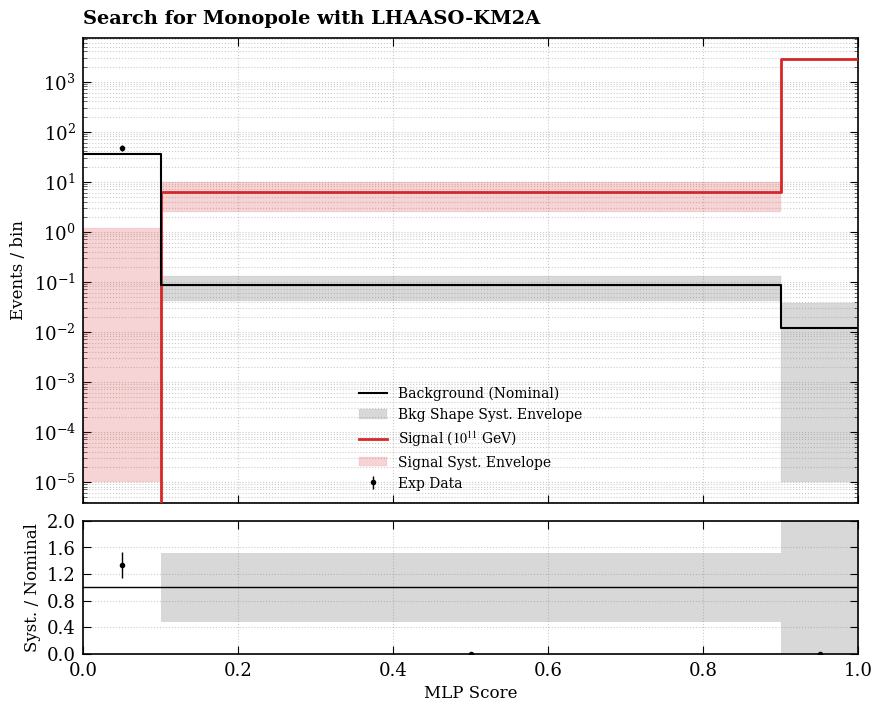

2853.329724488985
35.447474742536464
47
Background scaling factor: 1.0000 (from 35.45 to 35.45)
>>> ROOT file for RooStats generated successfully.
>>> HistFactory XML configuration file generated successfully.


In [79]:
def get_hist_counts(df, score_col='mlp_score', weight_col='weight', bins=25):
    
    counts, _ = np.histogram(df[score_col], bins=custom_bins, weights=df[weight_col])
    variances, _ = np.histogram(df[score_col], bins=custom_bins, weights=df[weight_col]**2)
    return counts, variances

from scipy.ndimage import gaussian_filter1d

def smooth_systematic_envelope(nominal, max_diff, sigma=1.0):
    """
    对系统误差的最大偏差进行平滑处理
    sigma: 平滑强度。通常设置在 1.0 - 1.5 之间。
           sigma 越大，曲线越平滑，但过大可能会抹去真实的物理趋势。
    """
    # 1. 对偏差进行平滑处理
    # 使用 mode='nearest' 处理边界，防止两端塌陷
    max_diff_smoothed = gaussian_filter1d(max_diff, sigma=sigma, mode='nearest')
    
    # 2. 重新生成对称包络线
    bkg_var_max_smoothed = nominal + max_diff_smoothed
    bkg_var_min_smoothed = nominal - max_diff_smoothed
    
    # 确保最小不会变成负数
    bkg_var_min_smoothed = np.maximum(bkg_var_min_smoothed, 0)
    
    return bkg_var_max_smoothed, bkg_var_min_smoothed


BINS_FIT = 10
BINS_PLOT = BINS_FIT
custom_bins = np.array([0.0, 0.1, 0.9, 1.0])
exp_final_hist, exp_final_var = get_hist_counts(exp_data, bins=BINS_FIT)

bkg_nominal_final_hist, bkg_nominal_final_var = get_hist_counts(bkg_nominal_train, bins=BINS_FIT)
bkg_var_final_hists = [get_hist_counts(bkg_var, bins=BINS_FIT)[0] for bkg_var in bkg_var_final_list]
bkg_var_final_vars = [get_hist_counts(bkg_var, bins=BINS_FIT)[1] for bkg_var in bkg_var_final_list]

sig_final_hist, sig_final_var = get_hist_counts(sig_nominal_train, bins=BINS_FIT)
sig_var_final_hists = [get_hist_counts(sig_var, bins=BINS_FIT)[0] for sig_var in sig_var_final_list]
sig_var_final_vars = [get_hist_counts(sig_var, bins=BINS_FIT)[1] for sig_var in sig_var_final_list]


TIMESCALE_FACTOR = 1438.81 * 86400  # 将事件数转换为年事件数
sig_final_hist = sig_final_hist * TIMESCALE_FACTOR
sig_var_final_hists = [sig_var_hist * TIMESCALE_FACTOR for sig_var_hist in sig_var_final_hists]
bkg_nominal_fit = bkg_nominal_final_hist  # 使用原始的 nominal 作为拟合基础

# 找到每个 bin 在所有变分中的真实最大值和最小值
bkg_all_array = np.array([bkg_nominal_final_hist] + bkg_var_final_hists)
bkg_var_max_raw = np.max(bkg_all_array, axis=0)
bkg_var_min_raw = np.min(bkg_all_array, axis=0)
#==========================================================
# 然后分别对这两条线做平滑
# bkg_var_max = gaussian_filter1d(bkg_var_max_raw, sigma=1.2, mode='nearest')
# bkg_var_min = gaussian_filter1d(bkg_var_min_raw, sigma=1.2, mode='nearest')
#==========================================================
# 1. 计算相对偏差 (注意保留正负号)
# rel_diff_up = (bkg_var_max_raw - bkg_nominal_final_hist) / bkg_nominal_final_hist
# rel_diff_down = (bkg_var_min_raw - bkg_nominal_final_hist) / bkg_nominal_final_hist
# # 2. 对相对偏差做平滑 (Sigma 稍微小一点，防止把高分区的特征抹平)
# rel_diff_up_smooth = gaussian_filter1d(rel_diff_up, sigma=1.0)
# rel_diff_down_smooth = gaussian_filter1d(rel_diff_down, sigma=1.0)
# # 3. 得到最终包络线
# bkg_var_max = bkg_nominal_final_hist * (1 + rel_diff_up_smooth)
# bkg_var_min = bkg_nominal_final_hist * (1 + rel_diff_down_smooth)
#==========================================================
# 计算均值和标准差
# bkg_hist_variations = np.array([bkg_var for bkg_var in bkg_var_final_hists])
# bkg_hist_variations_std = np.std(bkg_hist_variations, axis=0)
# bkg_hist_variations_mean = np.mean(bkg_hist_variations, axis=0)
# print("Bkg Variations Mean:", bkg_hist_variations_mean)
# print("Bkg Variations Std Dev:", bkg_hist_variations_std)
# bkg_var_max = bkg_hist_variations_mean + bkg_hist_variations_std
# bkg_var_min = bkg_hist_variations_mean - bkg_hist_variations_std
#==========================================================
#==========================================================
# 找到偏离最大,然后做对称镜像
bkg_hist_variations_diff = np.array([bkg_var - bkg_nominal_final_hist for bkg_var in bkg_var_final_hists])
bkg_hist_variations_diff = np.abs(bkg_hist_variations_diff)
bkg_hist_max_diff = np.max(bkg_hist_variations_diff, axis=0)
bkg_var_max = bkg_nominal_final_hist + bkg_hist_max_diff
bkg_var_min = bkg_nominal_final_hist - bkg_hist_max_diff
bkg_var_min = np.maximum(bkg_var_min, 1e-5) # 确保最小值不为负数
print("Bkg Var Max:", bkg_var_max)
print("Bkg Var Min:", bkg_var_min)
print("Bkg Nominal:", bkg_nominal_final_hist)
print("Bkg Max Diff:", bkg_hist_max_diff)
#==========================================================
# # 计算相对偏差
# rel_diff = bkg_hist_max_diff / bkg_nominal_final_hist
# x = np.linspace(0, 1, len(rel_diff))
# # 使用 2 阶多项式拟合趋势
# poly_coeffs = np.polyfit(x, rel_diff, 2)
# rel_diff_smoothed = np.polyval(poly_coeffs, x)
# # 重新应用
# bkg_var_max = bkg_nominal_final_hist * (1 + rel_diff_smoothed)
# bkg_var_min = bkg_nominal_final_hist * (1 - rel_diff_smoothed)
#==========================================================
# 调用平滑函数
# 建议先从 sigma=1.0 开始尝试
# 强制将 bkg_hist_max_diff 转换为 float 数组
bkg_var_max, bkg_var_min = smooth_systematic_envelope(bkg_nominal_final_hist.astype(float), bkg_hist_max_diff.astype(float), sigma=1)
bkg_var_min = np.maximum(bkg_var_min, 1e-5) # 确保最小值不为负数
#==========================================================
#sig var
sig_hist_variations = np.array([sig_var - sig_final_hist for sig_var in sig_var_final_hists])
sig_hist_variations_diff = np.abs(sig_hist_variations)
sig_hist_max_diff = np.max(sig_hist_variations_diff, axis=0)
sig_var_max, sig_var_min = smooth_systematic_envelope(sig_final_hist.astype(float), sig_hist_max_diff.astype(float), sigma=1)
sig_var_min = np.maximum(sig_var_min, 1e-5) # 确保最小值不为负数
print("sig diff", sig_hist_max_diff)
#==========================================================




import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 设置学术图表的默认样式
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = False # 如果你有 LaTeX 环境，设为 True 会更美观
def plot_final_with_full_envelope(nominal_bkg, bkg_max, bkg_min, signal, exp_data_hist, edges,
                                  sig_max, sig_min):
    """
    绘制带有不等宽分箱系统误差阴影带的图表
    edges: bin_edges, 长度为 n_bins + 1
    """
    # 转换为 float 保证计算安全
    bkg_max = np.asarray(bkg_max, dtype=float)
    bkg_min = np.asarray(bkg_min, dtype=float)
    nominal_bkg = np.asarray(nominal_bkg, dtype=float)
    signal = np.asarray(signal, dtype=float)
    sig_max = np.asarray(sig_max, dtype=float)
    sig_min = np.asarray(sig_min, dtype=float)
    exp_data_hist = np.asarray(exp_data_hist, dtype=float)
    edges = np.asarray(edges, dtype=float)

    # 计算 bin centers 和 widths (用于不等宽处理)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    # 创建画布
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.5, 1], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # =========================================================
    # 主图 (ax1): 不等宽阶梯填充
    # =========================================================
    
    # A. 绘制背景系统误差阴影带 (使用 step='post')
    # 为了让 step='post' 覆盖到最后一个 edge，需要在数组末尾补一个值
    # B. 绘制背景 Nominal 阶梯线
    ax1.step(edges, np.append(nominal_bkg, nominal_bkg[-1]), where='post', 
             color='black', lw=1.5, label='Background (Nominal)', zorder=10)
    ax1.fill_between(edges, 
                     np.append(bkg_min, bkg_min[-1]), 
                     np.append(bkg_max, bkg_max[-1]), 
                     step='post', color='gray', alpha=0.3, 
                     label='Bkg Shape Syst. Envelope', zorder=1)

    
    
    # C. 绘制信号阶梯线
    ax1.step(edges, np.append(signal, signal[-1]), where='post', 
             color='#d62728', lw=2, label='Signal ($10^{11}$ GeV)', zorder=5)
    ax1.fill_between(edges,
                     np.append(sig_min, sig_min[-1]),
                     np.append(sig_max, sig_max[-1]),
                     step='post', color='#d62728', alpha=0.2, label='Signal Syst. Envelope', zorder=2)
                    
    # D. 绘制实验数据 (点状带误差棒)
    # 统计误差使用 sqrt(N)，注意：数据点的 X 坐标必须在 centers
    ax1.errorbar(centers, exp_data_hist, yerr=np.sqrt(exp_data_hist), 
                 fmt='ko', markersize=4, capsize=0, elinewidth=1, label='Exp Data', zorder=15)
    
    # 主图修饰
    ax1.set_yscale('log')
    ax1.set_ylabel('Events / bin', fontsize=12)
    ax1.set_xlim(edges[0], edges[-1])
    ax1.legend(loc='best', frameon=False, fontsize=10)
    ax1.grid(True, which='both', ls=':', alpha=0.4, color='gray')
    ax1.set_title("Search for Monopole with LHAASO-KM2A", loc='left', fontsize=14, fontweight='bold', pad=10)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # =========================================================
    # 子图 (ax2): 不等宽 Ratio Plot
    # =========================================================
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_data = exp_data_hist / nominal_bkg
        ratio_max = bkg_max / nominal_bkg
        ratio_min = bkg_min / nominal_bkg
        # 处理可能出现的除以0的情况
        ratio_data = np.nan_to_num(ratio_data)
    
    # A. 绘制系统误差带 (Bar 方式完美适配不等宽)
    # 给 bar 传入 widths 数组，使得每个柱子宽度与 bin 宽度一致
    ax2.bar(centers, ratio_max - ratio_min, bottom=ratio_min, width=widths,
            color='gray', alpha=0.3, align='center', zorder=1)
    
    # B. 绘制 Data/Nominal 点
    ax2.errorbar(centers, ratio_data, yerr=np.sqrt(exp_data_hist)/nominal_bkg, 
                 fmt='ko', markersize=4, capsize=0, elinewidth=1, zorder=10)
    
    # 1.0 参考线
    ax2.axhline(1.0, color='black', lw=1, ls='-')
    
    # 子图修饰
    ax2.set_ylabel('Syst. / Nominal', fontsize=12)
    ax2.set_xlabel('MLP Score', fontsize=12)
    ax2.set_ylim(0.0, 2.0) # 根据实际偏移调整范围
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.4)) 
    ax2.grid(True, which='both', ls=':', alpha=0.4, color='gray')
    plt.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e11_pre-fit_with_envelope.pdf", dpi=300, bbox_inches='tight')
    plt.show()

plot_final_with_full_envelope(bkg_nominal_fit, bkg_var_max, bkg_var_min, sig_final_hist, exp_final_hist, custom_bins, sig_var_max, sig_var_min)
print(sig_final_hist.sum())
print(bkg_nominal_final_hist.sum())
print(exp_final_hist.sum())


import array
import ROOT
import numpy as np

# --- 0. 准备工作 ---
# 假设你的 MLP Score 范围是 [0, 1]，40 个 bin
BINS_EDGES = np.linspace(0, 1, len(exp_final_hist)+1) # 这里的 bin 数量要和 hist 的长度匹配
BINS_ARRAY = array.array('d', BINS_EDGES)

# 核心：计算背景缩放系数
# 将模板直方图的总面积缩放到 Sideband Fit 预测的 Total_Yield
current_bkg_integral = np.sum(bkg_nominal_final_hist)
bkg_scale = bkg_yields / current_bkg_integral
print(f"Background scaling factor: {bkg_scale:.4f} (from {current_bkg_integral:.2f} to {bkg_yields:.2f})")
def write_hist_pyroot(file_obj, name, counts, variances, bin_edges_array):
    """使用 PyROOT 写入直方图"""
    h = ROOT.TH1D(name, name, len(bin_edges_array)-1, bin_edges_array)
    h.Sumw2()
    for i in range(len(counts)):
        h.SetBinContent(i+1, counts[i])
        if variances is not None:
            h.SetBinError(i+1, np.sqrt(variances[i]))
        else:
            # 对于数据，默认使用泊松误差
            h.SetBinError(i+1, np.sqrt(counts[i]))
    h.SetDirectory(file_obj)
    h.Write()

# --- 1. 执行写入 ---
import os
os.makedirs("./upperlimit_DataDriven", exist_ok=True)
os.makedirs("./upperlimit_DataDriven/figures", exist_ok=True)
os.makedirs("./upperlimit_DataDriven/results", exist_ok=True)
f_out = ROOT.TFile("./upperlimit_DataDriven/inputs_for_roostats.root", "RECREATE")

# A. 写入 Data
write_hist_pyroot(f_out, "h_data", exp_final_hist, exp_final_var, BINS_ARRAY)

# B. 写入 Signal (已经乘以 TIMESCALE_FACTOR)
write_hist_pyroot(f_out, "h_sig_nom", sig_final_hist, sig_final_var, BINS_ARRAY)

# C. 写入 Background Nominal (缩放到预测产额)
# 注意：方差也要按比例平方缩放
write_hist_pyroot(f_out, "h_bkg_nom", 
                  bkg_nominal_final_hist * bkg_scale, 
                  bkg_nominal_final_var * (bkg_scale**2), 
                  BINS_ARRAY)

# D. 写入 Background Shape Systematics (Up/Down)
# HistFactory 的 HistoSys 需要 Up 和 Down 两个模板
write_hist_pyroot(f_out, "h_bkg_ShapeUp", 
                  bkg_var_max * bkg_scale, 
                  None, BINS_ARRAY) # 变分模板通常不单独计算 MC 统计误差
write_hist_pyroot(f_out, "h_bkg_ShapeDown", 
                  bkg_var_min * bkg_scale, 
                  None, BINS_ARRAY)
write_hist_pyroot(f_out, "h_sig_ShapeUp",
                  sig_var_max,
                  None, BINS_ARRAY)
write_hist_pyroot(f_out, "h_sig_ShapeDown",
                  sig_var_min,
                  None, BINS_ARRAY)
f_out.Close()
print(">>> ROOT file for RooStats generated successfully.")

XMLcontent=r"""
<!DOCTYPE Channel  SYSTEM 'HistFactorySchema.dtd'>

<Channel Name="LHAASO_Monopole_Channel" InputFile="./inputs_for_roostats.root">

  <Data HistoName="h_data" />
  <StatErrorConfig RelErrorThreshold="0.001" ConstraintType="Poisson" />

  <Sample Name="Background" HistoName="h_bkg_nom" NormalizeByTheory="True">
    <StatError Activate="True" />
    <NormFactor Name="mu_bkg" Val="1.0" Low="0.0" High="5.0" />
    <HistoSys Name="BkgShapeSyst" HistoNameLow="h_bkg_ShapeDown" HistoNameHigh="h_bkg_ShapeUp" />
  </Sample>

  <Sample Name="Signal" HistoName="h_sig_nom" NormalizeByTheory="True">
    <StatError Activate="True" />
    <NormFactor Name="mu" Val="1.0" Low="0.0" High="10.0" />
    <OverallSys Name="recE_shift" Low="0.80" High="1.20" />
    <OverallSys Name="R_ue_shift" Low="0.80" High="1.20" />
    <OverallSys Name="thetaRec_resolution" Low="0.80" High="1.20" />
    <HistoSys Name="SigShapeSyst" HistoNameLow="h_sig_ShapeDown" HistoNameHigh="h_sig_ShapeUp" />
  </Sample>

</Channel>


"""

XMLcontent = XMLcontent.replace('Name="recE_shift" Low="0.80" High="1.20"', f'Name="recE_shift" Low="{1-sig_recE_sys_percent:.4f}" High="{1+sig_recE_sys_percent:.4f}"')
XMLcontent = XMLcontent.replace('Name="R_ue_shift" Low="0.80" High="1.20"', f'Name="R_ue_shift" Low="{1-sig_Rue_sys_percent:.4f}" High="{1+sig_Rue_sys_percent:.4f}"')
XMLcontent = XMLcontent.replace('Name="thetaRec_resolution" Low="0.80" High="1.20"', f'Name="thetaRec_resolution" Low="{1-rec_theta_uncertainty_most:.4f}" High="{1+rec_theta_uncertainty_most:.4f}"')
with open("./upperlimit_DataDriven/LHAASO_Channel.xml", "w") as f:
    f.write(XMLcontent)
print(">>> HistFactory XML configuration file generated successfully.")

# cd ~/Filt_Event/UpperLimit/1e10/upperlimit_DataDriven
# hist2workspace driver.xml && root -l -b -q RunLimit_Plot.C